# 🏨 HotelSense AI

## An Explainable Multimodal Hotel Guest Satisfaction Prediction & Review Intelligence Platform

---

**HotelSense AI** is a complete, production-style machine-learning platform that predicts hotel guest
satisfaction from **both structured review metadata and free-text review content**, and turns raw reviews
into actionable **review intelligence**.

This single notebook runs end-to-end in Google Colab with minimal intervention. It will automatically:

1. **Acquire data** from public sources (with automatic mirror fallback + a fully-synthetic generator so it *always* runs).
2. **Validate, clean & engineer** structured + NLP features.
3. Perform **Aspect-Based Sentiment Analysis** across 16 hotel service aspects.
4. Produce **publication-quality EDA** (distributions, word clouds, n-grams, PCA/t-SNE/UMAP, correlations).
5. Train & compare **many classification and regression models** (LogReg, RF, XGBoost, LightGBM, CatBoost, MLP, neural nets, hybrid multimodal).
6. **Optimize hyperparameters with Optuna** (with pruning).
7. **Evaluate** with full metric suites (ROC/PR/calibration, residual/error plots).
8. Explain models with **SHAP** (global + local + waterfall + dependence).
9. Run **BERTopic** topic modeling & **transformer summarization**.
10. Build a **FAISS vector database** for semantic search + a **RAG assistant** (retrieval + cross-encoder reranking + open-source generator).
11. Launch a polished **multi-tab Gradio app**.
12. **Persist every artifact** and generate a **final HTML/PDF report**.

> **Design philosophy:** every heavy or network-dependent step is wrapped in defensive error handling with
> graceful fallbacks. If a transformer, a download, or an optional library is unavailable, the pipeline logs a
> warning and continues with a lighter alternative rather than crashing. Runtime is controlled by a single
> `SAMPLE_SIZE` knob in the configuration cell.

**Author:** Senior ML / NLP / MLOps Engineering pipeline · **Runtime target:** Google Colab (GPU optional)

# 1 · Environment Setup & Dependency Installation

Detect hardware, then install all required packages. Installation is idempotent and quiet; each optional
heavy library is installed in its own guarded step so a single failure does not abort the rest.

In [1]:
# ============================================================================
# 1.1 · Hardware detection + dependency installation
# ============================================================================
import subprocess, sys, os, importlib, warnings, time

warnings.filterwarnings("ignore")

def _run(cmd: str) -> int:
    """Run a shell command, streaming nothing, returning the exit code."""
    return subprocess.call(cmd, shell=True,
                           stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def pip_install(packages: str, label: str = "") -> None:
    """Install one or more pip packages quietly with a status line."""
    label = label or packages
    print(f"  ⏳ installing {label} ...", end=" ", flush=True)
    code = _run(f"{sys.executable} -m pip install -q {packages}")
    print("✅" if code == 0 else "⚠️  (non-fatal failure)")

IN_COLAB = "google.colab" in sys.modules
print(f"🌐 Running inside Google Colab: {IN_COLAB}")

# ---- GPU detection ---------------------------------------------------------
GPU_AVAILABLE = False
try:
    out = subprocess.check_output("nvidia-smi --query-gpu=name,memory.total "
                                  "--format=csv,noheader", shell=True,
                                  stderr=subprocess.DEVNULL).decode().strip()
    if out:
        GPU_AVAILABLE = True
        print(f"🚀 GPU detected: {out}")
except Exception:
    print("💻 No GPU detected — running on CPU (pipeline still works, just slower).")

# ---- Core scientific stack (usually preinstalled in Colab) -----------------
print("\n📦 Installing dependencies (this can take a few minutes on first run)...")
pip_install("pandas numpy scipy scikit-learn tqdm joblib", "core scientific stack")
pip_install("matplotlib seaborn plotly wordcloud", "visualization")
pip_install("xgboost lightgbm catboost", "gradient boosting libraries")
pip_install("optuna", "Optuna (HPO)")
pip_install("shap", "SHAP (explainability)")
pip_install("nltk textblob textstat vaderSentiment", "classic NLP toolkits")
pip_install("datasets huggingface_hub", "HuggingFace datasets/hub")
pip_install("sentence-transformers", "sentence-transformers")
pip_install("transformers accelerate", "transformers")
pip_install("faiss-cpu", "FAISS (vector DB)")
pip_install("gradio", "Gradio (UI)")
pip_install("umap-learn", "UMAP")
pip_install("bertopic", "BERTopic (topic modeling)")

# spaCy + small English model (guarded — NER/POS degrade gracefully if missing)
pip_install("spacy", "spaCy")
if _run(f"{sys.executable} -m spacy validate") != 0 or \
   importlib.util.find_spec("en_core_web_sm") is None:
    print("  ⏳ downloading spaCy en_core_web_sm ...", end=" ", flush=True)
    code = _run(f"{sys.executable} -m spacy download en_core_web_sm")
    print("✅" if code == 0 else "⚠️")

print("\n✅ Dependency installation complete.")

🌐 Running inside Google Colab: True
🚀 GPU detected: Tesla T4, 15360 MiB

📦 Installing dependencies (this can take a few minutes on first run)...
  ⏳ installing core scientific stack ... ✅
  ⏳ installing visualization ... ✅
  ⏳ installing gradient boosting libraries ... ✅
  ⏳ installing Optuna (HPO) ... ✅
  ⏳ installing SHAP (explainability) ... ✅
  ⏳ installing classic NLP toolkits ... ✅
  ⏳ installing HuggingFace datasets/hub ... ✅
  ⏳ installing sentence-transformers ... ✅
  ⏳ installing transformers ... ✅
  ⏳ installing FAISS (vector DB) ... ✅
  ⏳ installing Gradio (UI) ... ✅
  ⏳ installing UMAP ... ✅
  ⏳ installing BERTopic (topic modeling) ... ✅
  ⏳ installing spaCy ... ✅

✅ Dependency installation complete.


In [2]:
# ============================================================================
# 1.2 · Import libraries
# ============================================================================
import os, re, gc, json, math, time, random, logging, warnings, pickle
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Any, Callable, Dict, List, Optional, Tuple, Union
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import matplotlib
matplotlib.use("Agg") if not IN_COLAB else None
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

# ---- Torch / device --------------------------------------------------------
try:
    import torch
    DEVICE = "cuda" if (torch.cuda.is_available() and GPU_AVAILABLE) else "cpu"
except Exception:
    torch = None
    DEVICE = "cpu"
print(f"🧠 Torch device: {DEVICE}")

# ---- sklearn ---------------------------------------------------------------
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             precision_recall_curve, mean_absolute_error,
                             mean_squared_error, r2_score, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

print("✅ Core libraries imported.")

🧠 Torch device: cuda
✅ Core libraries imported.


# 2 · Configuration, Reproducibility & Project Scaffolding

A single `Config` dataclass controls every knob in the pipeline (paths, sample size, model toggles, seeds).
We fix all random seeds, build the directory tree, and configure logging here.

> **Tuning runtime:** lower `SAMPLE_SIZE` for a fast demo run (e.g. 5000) or raise it (e.g. 60000+) for a
> more thorough run. Expensive stages (transformer embeddings, UMAP, BERTopic, Optuna trials) are individually
> toggleable via the `*_ENABLED` / `*_TRIALS` fields.

In [3]:
# ============================================================================
# 2.1 · Configuration dataclass
# ============================================================================
@dataclass
class Config:
    """Central configuration object for the entire HotelSense AI pipeline."""
    project_name: str = "HotelSenseAI"
    seed: int = 42

    # ---- data sizing -------------------------------------------------------
    sample_size: int = 15_000        # rows kept after loading (controls runtime)
    max_text_chars: int = 2_000      # truncate very long reviews
    test_size: float = 0.2
    val_size: float = 0.1

    # ---- feature/model toggles --------------------------------------------
    transformer_embeddings_enabled: bool = True
    transformer_sentiment_sample: int = 1_500   # rows for heavy transformer sentiment/emotion
    umap_enabled: bool = True
    tsne_sample: int = 2_000
    bertopic_enabled: bool = True
    summarization_enabled: bool = True
    rag_enabled: bool = True
    gradio_enabled: bool = True
    optuna_trials: int = 20
    optuna_timeout: int = 300        # seconds cap per study

    # ---- model names -------------------------------------------------------
    embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"
    cross_encoder_model: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"
    summarizer_model: str = "sshleifer/distilbart-cnn-12-6"
    generator_model: str = "google/flan-t5-base"
    sentiment_model: str = "distilbert-base-uncased-finetuned-sst-2-english"
    emotion_model: str = "j-hartmann/emotion-english-distilroberta-base"

    # ---- paths (populated in __post_init__) --------------------------------
    root: str = "HotelSenseAI"
    paths: Dict[str, Path] = field(default_factory=dict)

    def __post_init__(self):
        base = Path(self.root)
        tree = {
            "root": base,
            "data": base / "data",
            "raw": base / "data" / "raw",
            "processed": base / "data" / "processed",
            "models": base / "models",
            "embeddings": base / "embeddings",
            "faiss": base / "faiss",
            "outputs": base / "outputs",
            "figures": base / "outputs" / "figures",
            "reports": base / "outputs" / "reports",
            "logs": base / "logs",
            "checkpoints": base / "checkpoints",
        }
        self.paths = tree


CONFIG = Config()

# ---- create directory tree -------------------------------------------------
for name, p in CONFIG.paths.items():
    p.mkdir(parents=True, exist_ok=True)
print("📁 Project directory tree created under:", CONFIG.paths["root"].resolve())
for name, p in CONFIG.paths.items():
    print(f"   {name:12s} -> {p}")

# ============================================================================
# 2.2 · Reproducibility — fix all seeds
# ============================================================================
def set_global_seed(seed: int = 42) -> None:
    """Fix seeds across random, numpy, torch (+cuda) and PYTHONHASHSEED."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    print(f"🎲 Global seed set to {seed}")

set_global_seed(CONFIG.seed)

# ============================================================================
# 2.3 · Logging
# ============================================================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.FileHandler(CONFIG.paths["logs"] / "hotelsense.log", mode="w"),
        logging.StreamHandler(sys.stdout),
    ],
)
logger = logging.getLogger("HotelSenseAI")
logger.info("Logger initialised. Configuration ready.")

# ============================================================================
# 2.4 · Small reusable helpers
# ============================================================================
def savefig(fig, name: str) -> Path:
    """Save a matplotlib figure into the figures directory and return the path."""
    path = CONFIG.paths["figures"] / name
    fig.savefig(path, dpi=130, bbox_inches="tight")
    return path

def timer(fn: Callable) -> Callable:
    """Decorator that logs the wall-clock runtime of a function."""
    def wrapper(*a, **k):
        t0 = time.time()
        out = fn(*a, **k)
        logger.info(f"⏱️  {fn.__name__} finished in {time.time()-t0:.1f}s")
        return out
    return wrapper

def safe(default=None, label: str = ""):
    """Decorator: run a function, log & swallow exceptions, return `default`."""
    def deco(fn):
        def wrapper(*a, **k):
            try:
                return fn(*a, **k)
            except Exception as e:
                logger.warning(f"⚠️  {label or fn.__name__} failed: {e}")
                return default
        return wrapper
    return deco

print("✅ Configuration, seeds, logging and helpers are ready.")

📁 Project directory tree created under: /content/HotelSenseAI
   root         -> HotelSenseAI
   data         -> HotelSenseAI/data
   raw          -> HotelSenseAI/data/raw
   processed    -> HotelSenseAI/data/processed
   models       -> HotelSenseAI/models
   embeddings   -> HotelSenseAI/embeddings
   faiss        -> HotelSenseAI/faiss
   outputs      -> HotelSenseAI/outputs
   figures      -> HotelSenseAI/outputs/figures
   reports      -> HotelSenseAI/outputs/reports
   logs         -> HotelSenseAI/logs
   checkpoints  -> HotelSenseAI/checkpoints
🎲 Global seed set to 42
✅ Configuration, seeds, logging and helpers are ready.


# 3 · Automated Data Acquisition (multi-source, self-healing)

The loader attempts several **public** sources in order and stops at the first success:

1. **HuggingFace Datasets** — several candidate hotel-review dataset IDs.
2. **Direct CSV mirrors** (HF hub / GitHub raw).
3. **Synthetic generator** — a realistic, aspect-aware review simulator used as a guaranteed fallback so
   the notebook *always* produces a working dataset even with no network access.

Whatever the source, everything is normalised into one canonical schema:
`hotel_name, hotel_location, positive_review, negative_review, review_text, review_score, average_score,
trip_type, room_type, nationality, stay_duration, review_date, lat, lng`.

In [4]:
# ============================================================================
# 3.1 · Canonical schema + synthetic generator + multi-source loader
# ============================================================================
CANON_COLS = ["hotel_name", "hotel_location", "positive_review", "negative_review",
              "review_text", "review_score", "average_score", "trip_type",
              "room_type", "nationality", "stay_duration", "review_date",
              "lat", "lng"]

# ---- vocabulary used by the synthetic generator & ABSA ---------------------
ASPECTS = ["cleanliness", "staff", "location", "breakfast", "food", "room",
           "wifi", "parking", "pool", "gym", "bathroom", "noise", "value",
           "comfort", "check-in", "customer service"]

_POS_TEMPLATES = {
    "cleanliness": ["spotlessly clean room", "immaculate and fresh throughout"],
    "staff": ["staff were friendly and helpful", "warm welcoming reception team"],
    "location": ["perfect central location", "close to everything we needed"],
    "breakfast": ["delicious varied breakfast buffet", "great breakfast selection"],
    "food": ["excellent restaurant food", "tasty meals every night"],
    "room": ["spacious comfortable room", "beautiful modern room"],
    "wifi": ["fast reliable wifi", "strong free wifi everywhere"],
    "parking": ["easy convenient parking", "free secure parking on site"],
    "pool": ["lovely clean pool", "relaxing heated pool"],
    "gym": ["well equipped gym", "great fitness centre"],
    "bathroom": ["sparkling spacious bathroom", "great powerful shower"],
    "noise": ["quiet peaceful room", "very calm and restful"],
    "value": ["great value for money", "excellent value stay"],
    "comfort": ["extremely comfortable beds", "cosy and comfortable"],
    "check-in": ["smooth fast check-in", "effortless early check-in"],
    "customer service": ["outstanding customer service", "attentive helpful service"],
}
_NEG_TEMPLATES = {
    "cleanliness": ["room was dirty and dusty", "unclean carpets and stained sheets"],
    "staff": ["rude unhelpful staff", "reception was unfriendly"],
    "location": ["inconvenient far location", "difficult area to reach"],
    "breakfast": ["poor limited breakfast", "cold disappointing breakfast"],
    "food": ["overpriced tasteless food", "bad restaurant meals"],
    "room": ["tiny cramped room", "outdated worn room"],
    "wifi": ["slow unreliable wifi", "wifi kept dropping constantly"],
    "parking": ["expensive difficult parking", "no parking available"],
    "pool": ["dirty cold pool", "pool was closed"],
    "gym": ["tiny outdated gym", "broken gym equipment"],
    "bathroom": ["mouldy small bathroom", "weak cold shower"],
    "noise": ["very noisy street all night", "thin walls could hear everything"],
    "value": ["overpriced poor value", "not worth the money"],
    "comfort": ["uncomfortable hard bed", "lumpy pillows bad sleep"],
    "check-in": ["long slow check-in queue", "chaotic check-in process"],
    "customer service": ["ignored by customer service", "unresponsive service team"],
}
_HOTELS = [f"{p} {s}" for p in
           ["Grand", "Royal", "Park", "City", "Harbour", "Plaza", "Garden",
            "Riverside", "Central", "Imperial", "Sunset", "Metropolitan"]
           for s in ["Hotel", "Palace", "Inn", "Suites", "Resort"]]
_CITIES = [("London, United Kingdom", 51.51, -0.13), ("Paris, France", 48.86, 2.35),
           ("Amsterdam, Netherlands", 52.37, 4.90), ("Barcelona, Spain", 41.39, 2.17),
           ("Vienna, Austria", 48.21, 16.37), ("Milan, Italy", 45.46, 9.19),
           ("Berlin, Germany", 52.52, 13.40), ("Rome, Italy", 41.90, 12.50)]
_NATIONS = ["United Kingdom", "United States", "Germany", "France", "Australia",
            "Netherlands", "Italy", "Spain", "Canada", "Ireland", "China", "India"]
_TRIPS = ["Leisure trip", "Business trip"]
_ROOMS = ["Standard Double Room", "Superior Double Room", "Deluxe King Room",
          "Twin Room", "Family Room", "Suite", "Single Room"]
_TRAVELERS = ["Solo traveler", "Couple", "Family with young children",
              "Group", "Family with older children"]


def generate_synthetic_reviews(n: int, seed: int = 42) -> pd.DataFrame:
    """Create a realistic, aspect-aware synthetic hotel-review dataset.

    Review score is generated from the balance of positive vs. negative aspect
    mentions plus noise, so downstream models & ABSA have genuine signal.
    """
    rng = random.Random(seed)
    rows: List[Dict[str, Any]] = []
    hotel_avg = {h: round(rng.uniform(7.0, 9.3), 1) for h in _HOTELS}
    for _ in range(n):
        hotel = rng.choice(_HOTELS)
        city, lat, lng = rng.choice(_CITIES)
        n_pos = rng.randint(0, 4)
        n_neg = rng.randint(0, 3)
        pos_aspects = rng.sample(ASPECTS, k=min(n_pos, len(ASPECTS)))
        neg_aspects = rng.sample(ASPECTS, k=min(n_neg, len(ASPECTS)))
        pos_txt = ". ".join(rng.choice(_POS_TEMPLATES[a]) for a in pos_aspects)
        neg_txt = ". ".join(rng.choice(_NEG_TEMPLATES[a]) for a in neg_aspects)
        if not pos_txt: pos_txt = "No Positive"
        if not neg_txt: neg_txt = "No Negative"
        # score driven by aspect balance (tuned for a balanced 3-class split,
        # reviews skewing slightly positive as in real booking data)
        base = 8.2 + 0.55 * n_pos - 1.05 * n_neg + rng.gauss(0, 1.2)
        score = float(min(10.0, max(2.5, base)))
        nights = rng.randint(1, 10)
        days_ago = rng.randint(1, 720)
        date = pd.Timestamp("2017-08-01") - pd.Timedelta(days=days_ago)
        rows.append({
            "hotel_name": hotel,
            "hotel_location": city,
            "positive_review": pos_txt,
            "negative_review": neg_txt,
            "review_score": round(score, 1),
            "average_score": hotel_avg[hotel],
            "trip_type": rng.choice(_TRIPS),
            "room_type": rng.choice(_ROOMS),
            "nationality": rng.choice(_NATIONS),
            "stay_duration": nights,
            "review_date": date,
            "traveler_type": rng.choice(_TRAVELERS),
            "lat": lat + rng.uniform(-0.05, 0.05),
            "lng": lng + rng.uniform(-0.05, 0.05),
        })
    df = pd.DataFrame(rows)
    df["review_text"] = (df["positive_review"].replace("No Positive", "") + ". "
                         + df["negative_review"].replace("No Negative", "")).str.strip(". ")
    return df


# ---- helpers to normalise the Booking.com "515k" style schema --------------
def _parse_tags(tag_val: Any) -> Dict[str, Any]:
    """Parse the Booking.com Tags field (list-like string) into structured fields."""
    out = {"trip_type": np.nan, "room_type": np.nan,
           "stay_duration": np.nan, "traveler_type": np.nan}
    try:
        if isinstance(tag_val, str):
            items = [t.strip(" []'\"") for t in re.split(r"',\s*'", tag_val.strip("[]"))]
        elif isinstance(tag_val, (list, tuple)):
            items = [str(t).strip() for t in tag_val]
        else:
            return out
        for it in items:
            low = it.lower()
            if "trip" in low:
                out["trip_type"] = it
            elif "night" in low:
                m = re.search(r"(\d+)", it)
                if m: out["stay_duration"] = int(m.group(1))
            elif "room" in low or "suite" in low or "double" in low or "twin" in low:
                out["room_type"] = it
            elif any(k in low for k in ["solo", "couple", "family", "group", "friends"]):
                out["traveler_type"] = it
    except Exception:
        pass
    return out


def standardize_booking_schema(df: pd.DataFrame) -> pd.DataFrame:
    """Map a Booking.com-style dataframe to the canonical schema."""
    ren = {}
    lower = {c.lower(): c for c in df.columns}
    def pick(*names):
        for n in names:
            if n in lower: return lower[n]
        return None
    col_hotel = pick("hotel_name")
    col_addr  = pick("hotel_address")
    col_pos   = pick("positive_review")
    col_neg   = pick("negative_review")
    col_score = pick("reviewer_score")
    col_avg   = pick("average_score")
    col_nat   = pick("reviewer_nationality")
    col_date  = pick("review_date")
    col_tags  = pick("tags")
    col_lat   = pick("lat", "latitude")
    col_lng   = pick("lng", "lon", "longitude")

    out = pd.DataFrame()
    out["hotel_name"] = df[col_hotel] if col_hotel else "Unknown Hotel"
    out["hotel_location"] = df[col_addr] if col_addr else "Unknown"
    out["positive_review"] = df[col_pos] if col_pos else ""
    out["negative_review"] = df[col_neg] if col_neg else ""
    out["review_score"] = pd.to_numeric(df[col_score], errors="coerce") if col_score else np.nan
    out["average_score"] = pd.to_numeric(df[col_avg], errors="coerce") if col_avg else np.nan
    out["nationality"] = df[col_nat].astype(str).str.strip() if col_nat else "Unknown"
    out["review_date"] = pd.to_datetime(df[col_date], errors="coerce") if col_date else pd.NaT
    if col_lat: out["lat"] = pd.to_numeric(df[col_lat], errors="coerce")
    if col_lng: out["lng"] = pd.to_numeric(df[col_lng], errors="coerce")

    if col_tags:
        parsed = df[col_tags].apply(_parse_tags).apply(pd.Series)
        for c in ["trip_type", "room_type", "stay_duration", "traveler_type"]:
            out[c] = parsed[c]
    else:
        for c in ["trip_type", "room_type", "stay_duration", "traveler_type"]:
            out[c] = np.nan

    out["review_text"] = (out["positive_review"].fillna("").astype(str)
                          .str.replace("No Positive", "", regex=False) + ". "
                          + out["negative_review"].fillna("").astype(str)
                          .str.replace("No Negative", "", regex=False)).str.strip(". ")
    return out


@timer
def load_hotel_reviews(cfg: Config) -> Tuple[pd.DataFrame, str]:
    """Try public sources in order; return (dataframe, source_label)."""
    n = cfg.sample_size

    # --- Attempt 1: HuggingFace datasets ----------------------------------
    hf_candidates = [
        ("ashraq/hotel-reviews", None),
        ("Datatab/hotel_reviews", None),
        ("Sifal/hotel_reviews", None),
    ]
    for ds_id, cfg_name in hf_candidates:
        try:
            from datasets import load_dataset
            logger.info(f"Trying HuggingFace dataset '{ds_id}' ...")
            ds = load_dataset(ds_id, cfg_name, split="train", streaming=True)
            rows = []
            for i, ex in enumerate(ds):
                rows.append(ex)
                if i + 1 >= n: break
            if rows:
                raw = pd.DataFrame(rows)
                std = standardize_booking_schema(raw)
                if std["review_text"].str.len().sum() > 0:
                    logger.info(f"✅ Loaded {len(std):,} rows from HF '{ds_id}'.")
                    return std, f"huggingface:{ds_id}"
        except Exception as e:
            logger.warning(f"HF '{ds_id}' unavailable: {e}")

    # --- Attempt 2: direct CSV mirrors ------------------------------------
    csv_mirrors = [
        "https://huggingface.co/datasets/ashraq/hotel-reviews/resolve/main/hotel_reviews.csv",
    ]
    for url in csv_mirrors:
        try:
            logger.info(f"Trying CSV mirror {url} ...")
            raw = pd.read_csv(url, nrows=n)
            std = standardize_booking_schema(raw)
            if len(std) and std["review_text"].str.len().sum() > 0:
                logger.info(f"✅ Loaded {len(std):,} rows from CSV mirror.")
                return std, f"csv:{url}"
        except Exception as e:
            logger.warning(f"CSV mirror failed: {e}")

    # --- Attempt 3: synthetic fallback (always works) ---------------------
    logger.warning("All remote sources failed — generating synthetic dataset.")
    std = generate_synthetic_reviews(n, seed=cfg.seed)
    return std, "synthetic"


df_raw, DATA_SOURCE = load_hotel_reviews(CONFIG)
logger.info(f"📊 Data source used: {DATA_SOURCE}  |  shape={df_raw.shape}")
df_raw.head(3)

README.md:   0%|          | 0.00/548 [00:00<?, ?B/s]

,hotel_name,hotel_location,positive_review,negative_review,review_score,average_score,trip_type,room_type,nationality,stay_duration,review_date,traveler_type,lat,lng,review_text
0,Metropolitan Resort,"Barcelona, Spain",easy convenient parking. cosy and comfortable,No Negative,8.9,7.9,Leisure trip,Suite,Spain,10,2016-09-12,Group,41.428468,2.184285,easy convenient parking. cosy and comfortable
1,Royal Resort,"Vienna, Austria",relaxing heated pool,lumpy pillows bad sleep,8.0,7.1,Business trip,Standard Double Room,United Kingdom,4,2017-03-12,Solo traveler,48.175284,16.335998,relaxing heated pool. lumpy pillows bad sleep
2,Central Suites,"Berlin, Germany",excellent value stay. fast reliable wifi. well...,No Negative,10.0,7.7,Leisure trip,Twin Room,United Kingdom,5,2016-05-12,Family with young children,52.567189,13.426196,excellent value stay. fast reliable wifi. well...


# 4 · Data Validation

Schema checks, type coercion, range validation and a quality report before any processing.

In [5]:
# ============================================================================
# 4.1 · Validation & quality report
# ============================================================================
def validate_dataframe(df: pd.DataFrame) -> Dict[str, Any]:
    """Run schema/type/range checks and return a structured quality report."""
    report: Dict[str, Any] = {}
    report["n_rows"], report["n_cols"] = df.shape
    report["missing_columns"] = [c for c in CANON_COLS if c not in df.columns]
    report["null_fraction"] = (df.isna().mean().round(4)).to_dict()
    report["duplicate_rows"] = int(df.duplicated().sum())

    if "review_score" in df:
        s = pd.to_numeric(df["review_score"], errors="coerce")
        report["score_min"] = float(np.nanmin(s)) if s.notna().any() else None
        report["score_max"] = float(np.nanmax(s)) if s.notna().any() else None
        report["score_out_of_range"] = int(((s < 0) | (s > 10)).sum())
    report["empty_reviews"] = int((df.get("review_text", pd.Series(dtype=str))
                                   .fillna("").str.len() == 0).sum())
    return report


val_report = validate_dataframe(df_raw)
print("🔎 DATA VALIDATION REPORT")
print("-" * 60)
for k, v in val_report.items():
    if isinstance(v, dict):
        print(f"{k}:")
        for kk, vv in v.items():
            print(f"    {kk:18s}: {vv}")
    else:
        print(f"{k:22s}: {v}")

assert val_report["n_rows"] > 0, "No data loaded!"
if val_report["missing_columns"]:
    logger.warning(f"Missing canonical columns: {val_report['missing_columns']}")
logger.info("✅ Validation complete.")

🔎 DATA VALIDATION REPORT
------------------------------------------------------------
n_rows                : 15000
n_cols                : 15
missing_columns       : []
null_fraction:
    hotel_name        : 0.0
    hotel_location    : 0.0
    positive_review   : 0.0
    negative_review   : 0.0
    review_score      : 0.0
    average_score     : 0.0
    trip_type         : 0.0
    room_type         : 0.0
    nationality       : 0.0
    stay_duration     : 0.0
    review_date       : 0.0
    traveler_type     : 0.0
    lat               : 0.0
    lng               : 0.0
    review_text       : 0.0
duplicate_rows        : 0
score_min             : 2.5
score_max             : 10.0
score_out_of_range    : 0
empty_reviews         : 722


# 5 · Data Cleaning

Deduplicate, coerce types, impute/normalise categorical metadata, derive the combined review text,
and drop rows that carry no usable signal.

In [6]:
# ============================================================================
# 5.1 · Cleaning pipeline
# ============================================================================
@timer
def clean_dataframe(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Return a cleaned copy of the canonical dataframe."""
    df = df.copy()

    # ensure all canonical columns exist
    for c in CANON_COLS + ["traveler_type"]:
        if c not in df.columns:
            df[c] = np.nan

    # text normalisation
    for c in ["positive_review", "negative_review", "review_text"]:
        df[c] = (df[c].fillna("").astype(str)
                 .str.replace(r"\s+", " ", regex=True).str.strip())
    # rebuild combined text if empty
    empty = df["review_text"].str.len() == 0
    df.loc[empty, "review_text"] = (
        df.loc[empty, "positive_review"] + ". " + df.loc[empty, "negative_review"]
    ).str.strip(". ")
    # remove Booking.com placeholder tokens everywhere so they never pollute
    # embeddings, semantic search, summaries or the review corpus
    for c in ["positive_review", "negative_review", "review_text"]:
        df[c] = (df[c].str.replace(r"\bNo Negative\b", "", regex=True)
                      .str.replace(r"\bNo Positive\b", "", regex=True)
                      .str.replace(r"\s+", " ", regex=True)
                      .str.strip(" ."))
    df["review_text"] = df["review_text"].str.slice(0, cfg.max_text_chars)

    # numeric coercion
    df["review_score"] = pd.to_numeric(df["review_score"], errors="coerce")
    df["average_score"] = pd.to_numeric(df["average_score"], errors="coerce")
    df["stay_duration"] = pd.to_numeric(df["stay_duration"], errors="coerce")
    df["lat"] = pd.to_numeric(df.get("lat"), errors="coerce")
    df["lng"] = pd.to_numeric(df.get("lng"), errors="coerce")

    # impute review_score from average_score when missing, else median
    df["review_score"] = df["review_score"].fillna(df["average_score"])
    med = df["review_score"].median()
    df["review_score"] = df["review_score"].fillna(med).clip(0, 10)
    df["average_score"] = df["average_score"].fillna(
        df.groupby("hotel_name")["review_score"].transform("mean")).fillna(med)

    # categorical clean-up
    for c in ["hotel_name", "hotel_location", "nationality", "trip_type",
              "room_type", "traveler_type"]:
        df[c] = df[c].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")

    # stay duration + dates
    df["stay_duration"] = df["stay_duration"].fillna(df["stay_duration"].median())
    df["stay_duration"] = df["stay_duration"].fillna(2).clip(1, 60)
    df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
    df["review_date"] = df["review_date"].fillna(pd.Timestamp("2017-01-01"))

    # drop exact duplicates & signal-less rows
    before = len(df)
    df = df.drop_duplicates(subset=["hotel_name", "review_text", "review_score"])
    df = df[df["review_text"].str.len() >= 3].reset_index(drop=True)
    logger.info(f"Cleaning removed {before - len(df):,} rows "
                f"({len(df):,} remain).")
    return df


df = clean_dataframe(df_raw, CONFIG)
print("✅ Cleaned dataset shape:", df.shape)
df[["hotel_name", "hotel_location", "review_score", "trip_type",
    "room_type", "nationality", "stay_duration"]].head()

✅ Cleaned dataset shape: (14265, 15)


,hotel_name,hotel_location,review_score,trip_type,room_type,nationality,stay_duration
0,Metropolitan Resort,"Barcelona, Spain",8.9,Leisure trip,Suite,Spain,10
1,Royal Resort,"Vienna, Austria",8.0,Business trip,Standard Double Room,United Kingdom,4
2,Central Suites,"Berlin, Germany",10.0,Leisure trip,Twin Room,United Kingdom,5
3,Garden Inn,"Paris, France",7.2,Business trip,Single Room,Australia,1
4,Royal Hotel,"Paris, France",8.2,Leisure trip,Suite,Australia,4


# 6 · Target Construction (Classification + Regression)

We build **two** supervised targets from `review_score` (0–10 scale):

* **Regression target** — `review_score` itself.
* **Classification target** — a 3-class satisfaction label:
  `Unsatisfied` (score < 7), `Neutral` (7 ≤ score < 8.5), `Satisfied` (score ≥ 8.5).

These thresholds follow the common Booking.com convention where scores below 7 signal dissatisfaction.

In [7]:
# ============================================================================
# 6.1 · Build classification & regression targets
# ============================================================================
def satisfaction_label(score: float) -> str:
    if score < 7.0:   return "Unsatisfied"
    if score < 8.5:   return "Neutral"
    return "Satisfied"

df["satisfaction"] = df["review_score"].apply(satisfaction_label)
CLASS_ORDER = ["Unsatisfied", "Neutral", "Satisfied"]
df["satisfaction"] = pd.Categorical(df["satisfaction"], categories=CLASS_ORDER, ordered=True)

print("🎯 Classification target distribution:")
print(df["satisfaction"].value_counts().reindex(CLASS_ORDER))
print(f"\n🎯 Regression target — review_score: "
      f"mean={df['review_score'].mean():.2f}, std={df['review_score'].std():.2f}")

🎯 Classification target distribution:
satisfaction
Unsatisfied    5070
Neutral        4177
Satisfied      5018
Name: count, dtype: int64

🎯 Regression target — review_score: mean=7.61, std=1.70


# 7 · Exploratory Data Analysis (publication-quality)

Distributions, categorical breakdowns, temporal trends, correlations, word clouds and n-gram analysis.
All figures are saved to `outputs/figures/`.

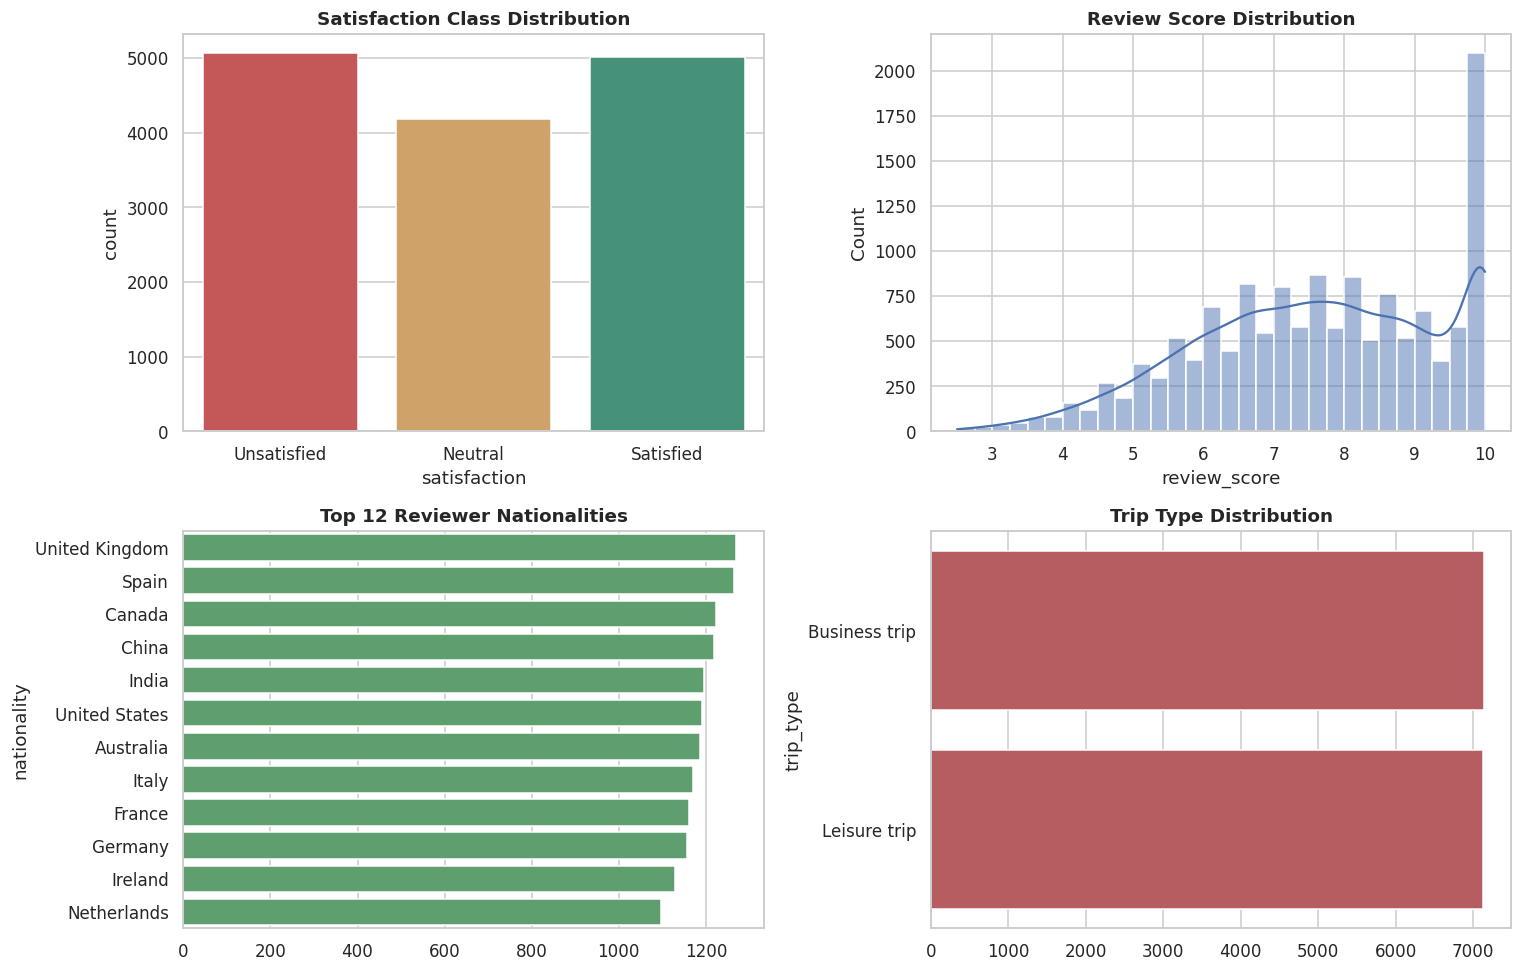

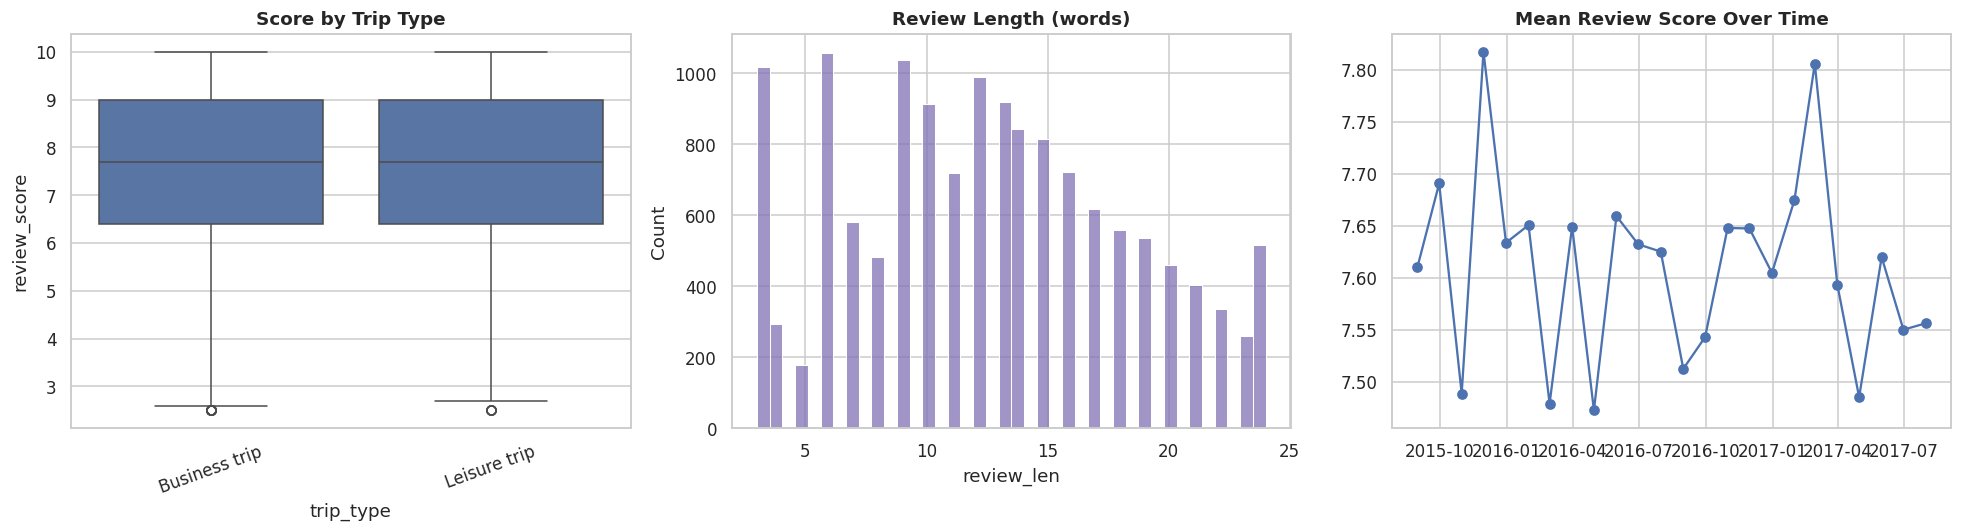

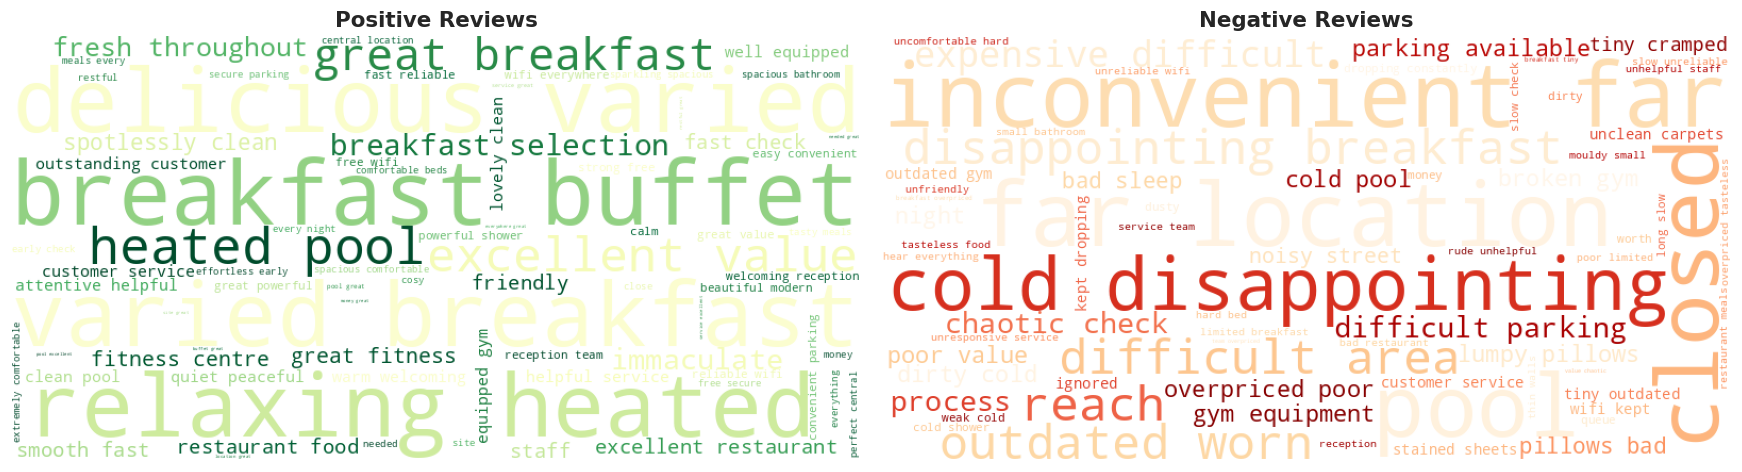

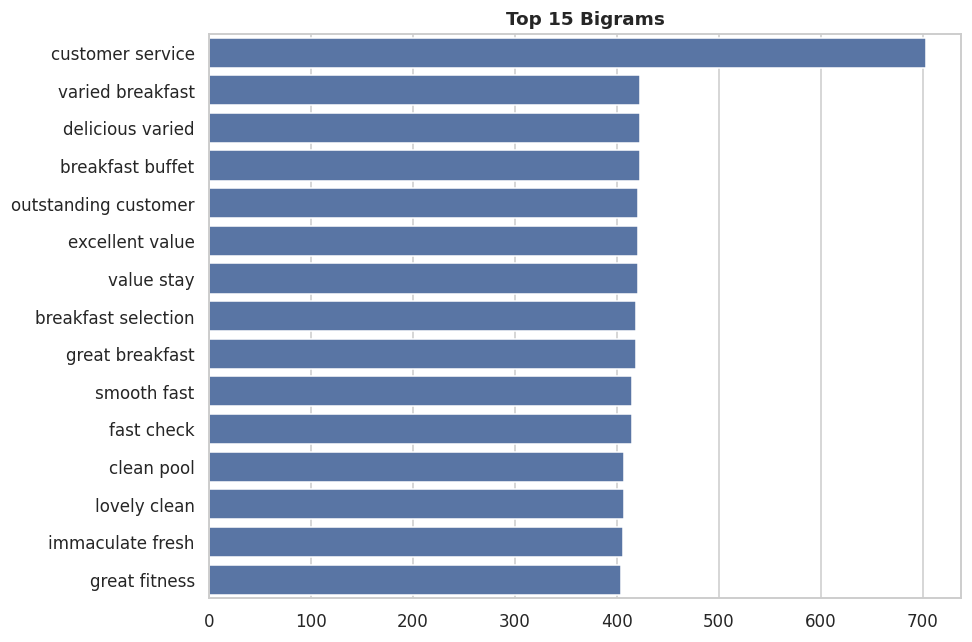

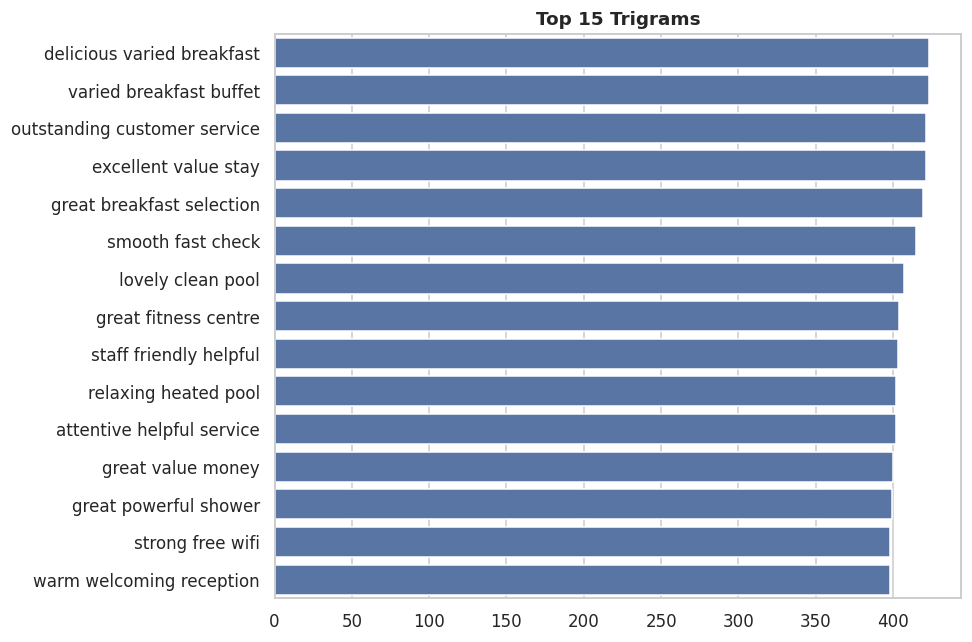

In [8]:
# ============================================================================
# 7.1 · Distributions: satisfaction class, score, categorical breakdowns
# ============================================================================
PALETTE = {"Unsatisfied": "#d64545", "Neutral": "#e0a458", "Satisfied": "#3a9d7e"}

@safe(label="eda_distributions")
def eda_distributions(df: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    order = CLASS_ORDER
    sns.countplot(data=df, x="satisfaction", order=order,
                  palette=[PALETTE[c] for c in order], ax=axes[0, 0])
    axes[0, 0].set_title("Satisfaction Class Distribution", fontweight="bold")

    sns.histplot(df["review_score"], bins=30, kde=True, color="#4c72b0", ax=axes[0, 1])
    axes[0, 1].set_title("Review Score Distribution", fontweight="bold")

    top_nat = df["nationality"].value_counts().head(12)
    sns.barplot(x=top_nat.values, y=top_nat.index, color="#55a868", ax=axes[1, 0])
    axes[1, 0].set_title("Top 12 Reviewer Nationalities", fontweight="bold")

    tt = df["trip_type"].value_counts().head(8)
    sns.barplot(x=tt.values, y=tt.index, color="#c44e52", ax=axes[1, 1])
    axes[1, 1].set_title("Trip Type Distribution", fontweight="bold")
    plt.tight_layout()
    savefig(fig, "eda_distributions.png")
    plt.show()

eda_distributions(df)

# ============================================================================
# 7.2 · Score by trip type & review length; temporal trend
# ============================================================================
@safe(label="eda_relations")
def eda_relations(df: pd.DataFrame):
    df = df.copy()
    df["review_len"] = df["review_text"].str.split().apply(len)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.boxplot(data=df, x="trip_type", y="review_score",
                order=df["trip_type"].value_counts().head(4).index, ax=axes[0])
    axes[0].set_title("Score by Trip Type", fontweight="bold")
    axes[0].tick_params(axis="x", rotation=20)

    sns.histplot(df["review_len"].clip(upper=df["review_len"].quantile(0.98)),
                 bins=40, color="#8172b3", ax=axes[1])
    axes[1].set_title("Review Length (words)", fontweight="bold")

    ts = (df.set_index("review_date").sort_index()
            .resample("M")["review_score"].mean())
    axes[2].plot(ts.index, ts.values, marker="o", color="#4c72b0")
    axes[2].set_title("Mean Review Score Over Time", fontweight="bold")
    plt.tight_layout()
    savefig(fig, "eda_relations.png")
    plt.show()

eda_relations(df)

# ============================================================================
# 7.3 · Word clouds (positive vs negative) + most-common n-grams
# ============================================================================
@safe(label="eda_wordclouds")
def eda_wordclouds(df: pd.DataFrame):
    from wordcloud import WordCloud, STOPWORDS
    sw = set(STOPWORDS) | {"hotel", "room", "stay", "stayed", "No", "Negative", "Positive"}
    pos_text = " ".join(df["positive_review"].astype(str).sample(
        min(4000, len(df)), random_state=CONFIG.seed))
    neg_text = " ".join(df["negative_review"].astype(str).sample(
        min(4000, len(df)), random_state=CONFIG.seed))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, text, title, cmap in [
        (axes[0], pos_text, "Positive Reviews", "YlGn"),
        (axes[1], neg_text, "Negative Reviews", "OrRd")]:
        wc = WordCloud(width=800, height=400, background_color="white",
                       stopwords=sw, colormap=cmap).generate(text or "none")
        ax.imshow(wc); ax.axis("off"); ax.set_title(title, fontweight="bold", fontsize=14)
    plt.tight_layout(); savefig(fig, "eda_wordclouds.png"); plt.show()

eda_wordclouds(df)

@safe(label="eda_ngrams")
def eda_ngrams(df: pd.DataFrame, ngram=(2, 2), top=15, title="Bigrams"):
    cv = CountVectorizer(ngram_range=ngram, stop_words="english", max_features=4000)
    X = cv.fit_transform(df["review_text"].sample(min(6000, len(df)),
                                                  random_state=CONFIG.seed))
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(cv.get_feature_names_out())
    idx = freqs.argsort()[::-1][:top]
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(x=freqs[idx], y=vocab[idx], color="#4c72b0", ax=ax)
    ax.set_title(f"Top {top} {title}", fontweight="bold")
    plt.tight_layout(); savefig(fig, f"eda_{title.lower()}.png"); plt.show()

eda_ngrams(df, (2, 2), title="Bigrams")
eda_ngrams(df, (3, 3), title="Trigrams")

# 8 · Advanced NLP Pipeline

Text cleaning, stopword removal, lemmatization, readability, POS statistics, NER, keyword extraction and
classic + transformer sentiment/emotion. Heavy transformer scoring runs on a configurable subsample; the
full corpus is scored with fast lexicon methods (VADER) so nothing stalls.

In [9]:
# ============================================================================
# 8.1 · NLP resources (NLTK + spaCy + VADER) with graceful fallbacks
# ============================================================================
import nltk
for pkg in ["stopwords", "wordnet", "omw-1.4", "punkt", "averaged_perceptron_tagger"]:
    try: nltk.download(pkg, quiet=True)
    except Exception: pass

from nltk.corpus import stopwords as nltk_sw
from nltk.stem import WordNetLemmatizer
try:
    STOPWORDS_EN = set(nltk_sw.words("english"))
except Exception:
    STOPWORDS_EN = set("a an the and or but if then of to in on for with at by from".split())
LEMMATIZER = WordNetLemmatizer()

# spaCy (POS + NER) — optional
try:
    import spacy
    NLP_SPACY = spacy.load("en_core_web_sm", disable=["parser"])
    SPACY_OK = True
    logger.info("spaCy en_core_web_sm loaded (POS + NER enabled).")
except Exception as e:
    NLP_SPACY, SPACY_OK = None, False
    logger.warning(f"spaCy unavailable — POS/NER will be skipped: {e}")

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
VADER = SentimentIntensityAnalyzer()
import textstat
try:
    from textblob import TextBlob
    TEXTBLOB_OK = True
except Exception:
    TEXTBLOB_OK = False

_token_re = re.compile(r"[a-zA-Z][a-zA-Z']+")

def clean_text(text: str, lemmatize: bool = True) -> str:
    """Lowercase, strip non-alpha, remove stopwords and (optionally) lemmatize."""
    text = str(text).lower()
    tokens = _token_re.findall(text)
    tokens = [t for t in tokens if t not in STOPWORDS_EN and len(t) > 2]
    if lemmatize:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return " ".join(tokens)

print("🧹 Building cleaned-token column ...")
tqdm.pandas(desc="clean_text")
df["clean_text"] = df["review_text"].progress_apply(clean_text)

# ============================================================================
# 8.2 · Lightweight per-row NLP statistics (fast, whole corpus)
# ============================================================================
def basic_text_stats(text: str) -> Dict[str, float]:
    words = str(text).split()
    n_words = len(words)
    n_chars = len(str(text))
    sents = max(1, str(text).count(".") + str(text).count("!") + str(text).count("?"))
    upper = sum(1 for c in str(text) if c.isupper())
    return {
        "review_len_words": n_words,
        "review_len_chars": n_chars,
        "avg_word_len": (n_chars / n_words) if n_words else 0.0,
        "avg_sentence_len": n_words / sents,
        "uppercase_ratio": upper / max(1, n_chars),
        "exclamation_count": str(text).count("!"),
        "question_count": str(text).count("?"),
        "vader_compound": VADER.polarity_scores(str(text))["compound"],
    }

print("📐 Computing text statistics + VADER sentiment (full corpus) ...")
stats = df["review_text"].progress_apply(basic_text_stats).apply(pd.Series)
df = pd.concat([df, stats], axis=1)

# readability + TextBlob polarity/subjectivity
@safe(default=0.0, label="readability")
def flesch(t): return textstat.flesch_reading_ease(str(t))
df["readability_flesch"] = df["review_text"].progress_apply(flesch)
if TEXTBLOB_OK:
    df["tb_polarity"] = df["review_text"].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
    df["tb_subjectivity"] = df["review_text"].apply(lambda t: TextBlob(str(t)).sentiment.subjectivity)
else:
    df["tb_polarity"] = df["vader_compound"]
    df["tb_subjectivity"] = 0.5

# ============================================================================
# 8.3 · POS statistics + NER on a sample (spaCy, optional)
# ============================================================================
@safe(default=None, label="spacy_pos_ner")
def spacy_enrich(df: pd.DataFrame, sample: int = 1500):
    if not SPACY_OK:
        return None
    idx = df.sample(min(sample, len(df)), random_state=CONFIG.seed).index
    pos_counts, ents = defaultdict(int), Counter()
    for doc in NLP_SPACY.pipe(df.loc[idx, "review_text"].astype(str).tolist(),
                              batch_size=64):
        for tok in doc:
            pos_counts[tok.pos_] += 1
        for ent in doc.ents:
            ents[ent.label_] += 1
    return dict(pos_counts), ents

pos_stats = spacy_enrich(df, 1500)
if pos_stats:
    print("🔤 POS tag counts (sample):", dict(sorted(pos_stats[0].items(),
          key=lambda x: -x[1])[:8]))
    print("🏷️  Named-entity types (sample):", dict(pos_stats[1].most_common(8)))

# ============================================================================
# 8.4 · Transformer sentiment + emotion on a subsample (optional, GPU-aware)
# ============================================================================
TRANSFORMER_SENTIMENT = None
@safe(default=None, label="transformer_sentiment")
def build_transformer_sentiment(df: pd.DataFrame, cfg: Config):
    from transformers import pipeline
    dev = 0 if DEVICE == "cuda" else -1
    sent_pipe = pipeline("sentiment-analysis", model=cfg.sentiment_model,
                         device=dev, truncation=True)
    emo_pipe = pipeline("text-classification", model=cfg.emotion_model,
                        device=dev, truncation=True, top_k=1)
    idx = df.sample(min(cfg.transformer_sentiment_sample, len(df)),
                    random_state=cfg.seed).index
    texts = df.loc[idx, "review_text"].astype(str).str.slice(0, 400).tolist()
    sent = sent_pipe(texts, batch_size=32)
    emo = emo_pipe(texts, batch_size=32)
    df.loc[idx, "tf_sentiment"] = [s["label"] for s in sent]
    df.loc[idx, "tf_emotion"] = [e[0]["label"] if isinstance(e, list) else e["label"]
                                 for e in emo]
    return sent_pipe

if CONFIG.transformer_embeddings_enabled:
    print("🤖 Scoring transformer sentiment/emotion on a subsample ...")
    TRANSFORMER_SENTIMENT = build_transformer_sentiment(df, CONFIG)
    if "tf_emotion" in df:
        print("😀 Emotion distribution (sample):")
        print(df["tf_emotion"].value_counts(dropna=True).head(8))

print("✅ NLP pipeline complete.")

🧹 Building cleaned-token column ...


clean_text:   0%|          | 0/14265 [00:00<?, ?it/s]

📐 Computing text statistics + VADER sentiment (full corpus) ...


clean_text:   0%|          | 0/14265 [00:00<?, ?it/s]

clean_text:   0%|          | 0/14265 [00:00<?, ?it/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  329MB            

model.safetensors: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

😀 Emotion distribution (sample):
tf_emotion
nan         12765
joy           752
sadness       525
neutral       104
anger          59
surprise       43
disgust        13
fear            4
Name: count, dtype: int64
✅ NLP pipeline complete.


# 9 · Aspect-Based Sentiment Analysis (ABSA)

For each of 16 hotel aspects (cleanliness, staff, location, breakfast, food, room, wifi, parking, pool, gym,
bathroom, noise, value, comfort, check-in, customer service) we detect whether the aspect is mentioned and,
if so, score the surrounding context sentiment into **positive / neutral / negative** using a lexicon + VADER
window approach (fast and fully offline). Aggregate aspect sentiment is used for EDA and as model features.

🧩 Running aspect-based sentiment analysis ...


clean_text:   0%|          | 0/14265 [00:00<?, ?it/s]

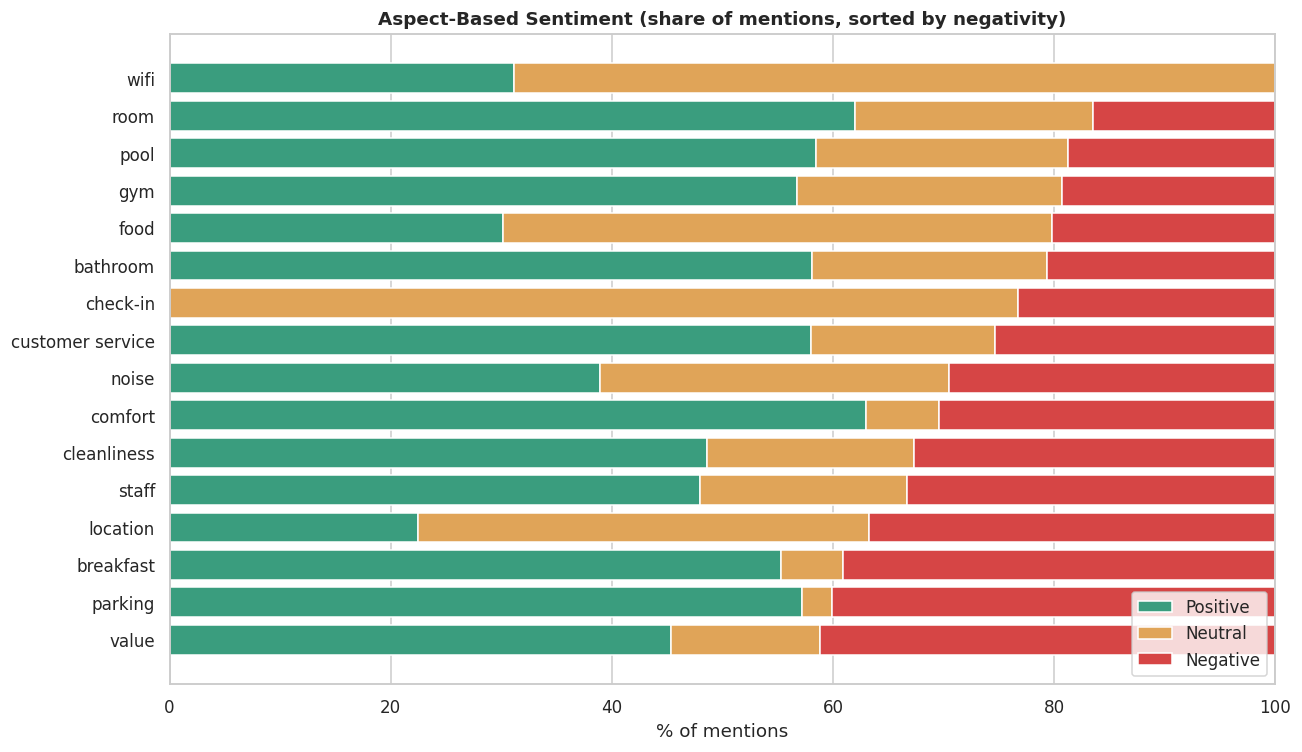


🔝 Most-complained-about aspects:
     aspect  negative  mentions
      value 41.186240      4215
    parking 40.134745      3117
  breakfast 39.129043      3123
   location 36.796650      3821
      staff 33.297268      3697
cleanliness 32.657032      3598


In [10]:
# ============================================================================
# 9.1 · Aspect lexicon + windowed sentiment scoring
# ============================================================================
ASPECT_KEYWORDS: Dict[str, List[str]] = {
    "cleanliness": ["clean", "dirty", "dust", "spotless", "hygiene", "stain", "filthy"],
    "staff":       ["staff", "reception", "receptionist", "employee", "manager", "team"],
    "location":    ["location", "located", "central", "area", "neighbourhood", "distance", "close"],
    "breakfast":   ["breakfast", "buffet", "morning meal", "continental"],
    "food":        ["food", "restaurant", "dinner", "meal", "cuisine", "lunch", "menu"],
    "room":        ["room", "suite", "bedroom", "space", "spacious", "cramped"],
    "wifi":        ["wifi", "wi-fi", "internet", "connection", "network"],
    "parking":     ["parking", "garage", "car park", "valet"],
    "pool":        ["pool", "swimming", "jacuzzi"],
    "gym":         ["gym", "fitness", "workout", "exercise"],
    "bathroom":    ["bathroom", "shower", "toilet", "bath", "sink"],
    "noise":       ["noise", "noisy", "quiet", "loud", "soundproof", "walls"],
    "value":       ["value", "price", "expensive", "cheap", "overpriced", "worth", "money"],
    "comfort":     ["comfort", "comfortable", "bed", "mattress", "pillow", "cosy"],
    "check-in":    ["check-in", "checkin", "check in", "checkout", "check-out", "arrival"],
    "customer service": ["service", "helpful", "responsive", "attentive", "assistance", "support"],
}

_sent_split = re.compile(r"[.!?]")

def aspect_sentiment(text: str) -> Dict[str, str]:
    """Return {aspect: 'positive'|'neutral'|'negative'|'absent'} for one review."""
    text_l = str(text).lower()
    sentences = [s.strip() for s in _sent_split.split(text_l) if s.strip()]
    out: Dict[str, str] = {}
    for aspect, kws in ASPECT_KEYWORDS.items():
        hit_scores = []
        for s in sentences:
            if any(kw in s for kw in kws):
                hit_scores.append(VADER.polarity_scores(s)["compound"])
        if not hit_scores:
            out[aspect] = "absent"
        else:
            m = float(np.mean(hit_scores))
            out[aspect] = "positive" if m > 0.15 else ("negative" if m < -0.15 else "neutral")
    return out

print("🧩 Running aspect-based sentiment analysis ...")
absa_records = df["review_text"].progress_apply(aspect_sentiment).apply(pd.Series)
absa_records = absa_records.add_prefix("aspect_")
df = pd.concat([df, absa_records], axis=1)

# numeric aspect feature: +1 pos / 0 neutral / -1 neg / NaN absent -> 0
_map = {"positive": 1.0, "neutral": 0.0, "negative": -1.0, "absent": 0.0}
for aspect in ASPECT_KEYWORDS:
    df[f"aspectscore_{aspect}"] = df[f"aspect_{aspect}"].map(_map).fillna(0.0)

# ============================================================================
# 9.2 · Aggregate aspect sentiment visualisation
# ============================================================================
@safe(label="absa_plot")
def plot_absa(df: pd.DataFrame):
    rows = []
    for aspect in ASPECT_KEYWORDS:
        vc = df[f"aspect_{aspect}"].value_counts()
        present = vc.drop(labels=["absent"], errors="ignore").sum()
        if present == 0: continue
        rows.append({
            "aspect": aspect,
            "positive": vc.get("positive", 0) / present * 100,
            "neutral":  vc.get("neutral", 0) / present * 100,
            "negative": vc.get("negative", 0) / present * 100,
            "mentions": int(present),
        })
    adf = pd.DataFrame(rows).sort_values("negative", ascending=False)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(adf["aspect"], adf["positive"], color="#3a9d7e", label="Positive")
    ax.barh(adf["aspect"], adf["neutral"], left=adf["positive"],
            color="#e0a458", label="Neutral")
    ax.barh(adf["aspect"], adf["negative"],
            left=adf["positive"] + adf["neutral"], color="#d64545", label="Negative")
    ax.set_xlabel("% of mentions"); ax.set_title(
        "Aspect-Based Sentiment (share of mentions, sorted by negativity)",
        fontweight="bold")
    ax.legend(loc="lower right")
    plt.tight_layout(); savefig(fig, "absa_sentiment.png"); plt.show()
    return adf

ASPECT_SUMMARY = plot_absa(df)
print("\n🔝 Most-complained-about aspects:")
if ASPECT_SUMMARY is not None:
    print(ASPECT_SUMMARY[["aspect", "negative", "mentions"]].head(6).to_string(index=False))

# 10 · Feature Engineering

Temporal features (month, season, weekend, holiday indicator), rating deviation, categorical encodings,
and redundant-feature removal via correlation pruning. This yields the structured feature matrix used by the
tabular models and the multimodal hybrid.

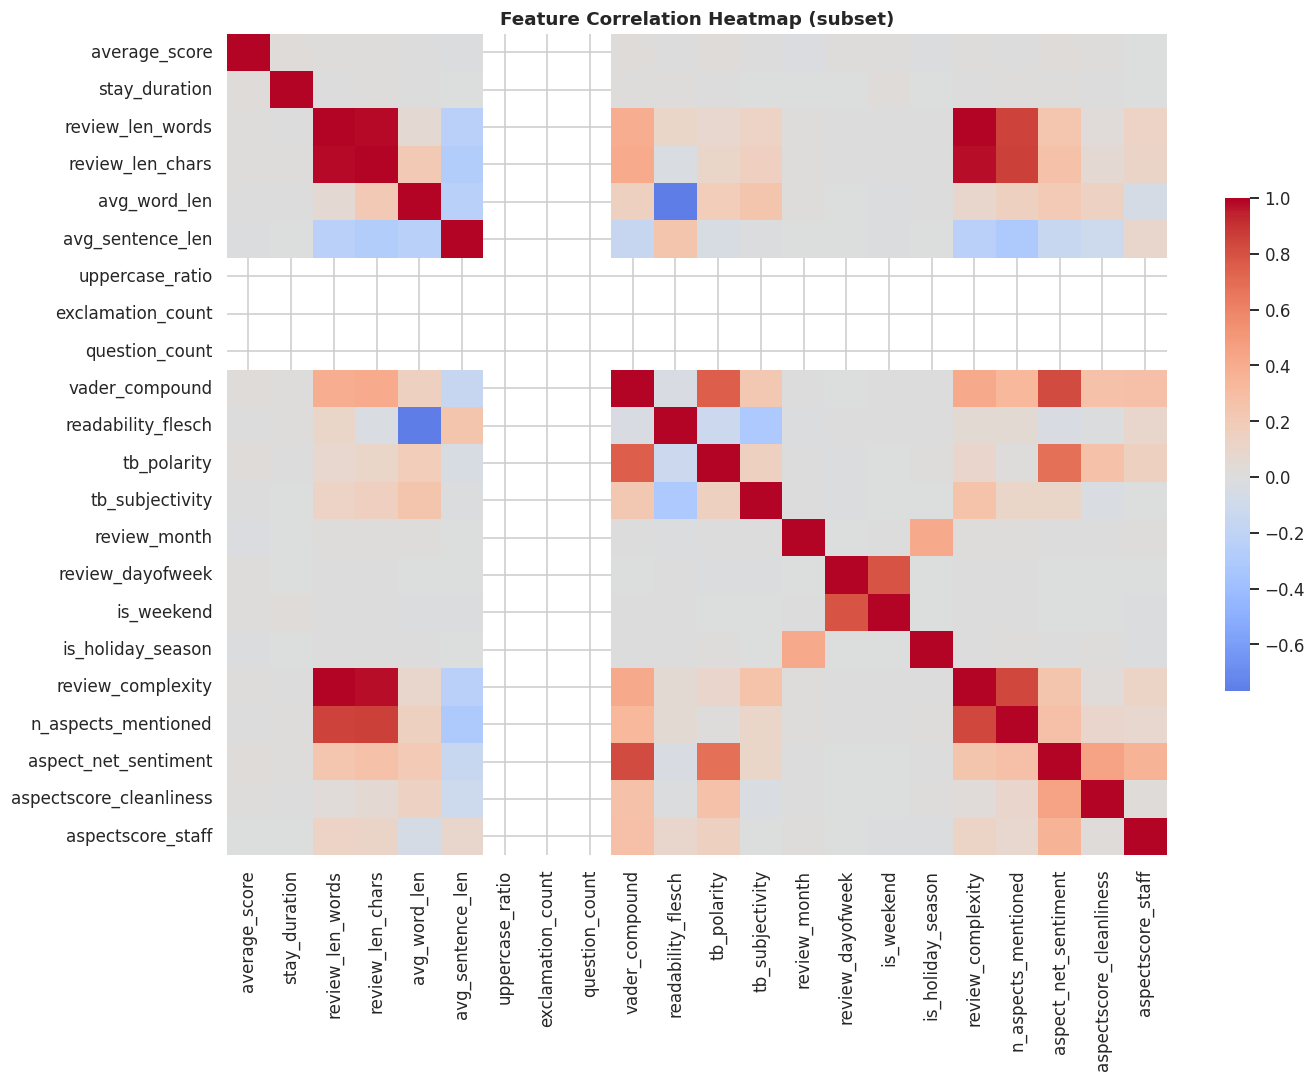

✅ 39 structured features retained.
['average_score', 'stay_duration', 'review_len_words', 'avg_word_len', 'avg_sentence_len', 'uppercase_ratio', 'exclamation_count', 'question_count', 'vader_compound', 'readability_flesch', 'tb_polarity', 'tb_subjectivity', 'review_month', 'review_dayofweek', 'is_weekend', 'is_holiday_season', 'n_aspects_mentioned', 'aspect_net_sentiment', 'aspectscore_cleanliness', 'aspectscore_staff', 'aspectscore_location', 'aspectscore_breakfast', 'aspectscore_food', 'aspectscore_room', 'aspectscore_wifi', 'aspectscore_parking', 'aspectscore_pool', 'aspectscore_gym', 'aspectscore_bathroom', 'aspectscore_noise', 'aspectscore_value', 'aspectscore_comfort', 'aspectscore_check-in', 'aspectscore_customer service', 'trip_type_enc', 'room_type_enc', 'nationality_enc', 'season_enc', 'traveler_type_enc']


In [11]:
# ============================================================================
# 10.1 · Temporal + derived structured features
# ============================================================================
def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    d = df["review_date"]
    df["review_month"] = d.dt.month.fillna(1).astype(int)
    df["review_year"] = d.dt.year.fillna(2017).astype(int)
    df["review_dayofweek"] = d.dt.dayofweek.fillna(0).astype(int)
    df["is_weekend"] = (df["review_dayofweek"] >= 5).astype(int)
    season_map = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring",
                  5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer",
                  9: "Autumn", 10: "Autumn", 11: "Autumn"}
    df["season"] = df["review_month"].map(season_map)
    # crude holiday indicator: Dec, or Jul-Aug summer peak
    df["is_holiday_season"] = df["review_month"].isin([7, 8, 12]).astype(int)
    # rating deviation vs. hotel average
    df["rating_deviation"] = df["review_score"] - df["average_score"]
    # review complexity proxy
    df["review_complexity"] = (df["review_len_words"] * (1 + df["tb_subjectivity"])).round(2)
    # aspect coverage
    aspect_cols = [c for c in df.columns if c.startswith("aspectscore_")]
    df["n_aspects_mentioned"] = (df[[f"aspect_{a}" for a in ASPECT_KEYWORDS]]
                                 != "absent").sum(axis=1)
    df["aspect_net_sentiment"] = df[aspect_cols].sum(axis=1)
    return df

df = add_temporal_features(df)

# ============================================================================
# 10.2 · Categorical encoding
# ============================================================================
STRUCTURED_NUMERIC = [
    "average_score", "stay_duration", "review_len_words", "review_len_chars",
    "avg_word_len", "avg_sentence_len", "uppercase_ratio", "exclamation_count",
    "question_count", "vader_compound", "readability_flesch", "tb_polarity",
    "tb_subjectivity", "review_month", "review_dayofweek", "is_weekend",
    "is_holiday_season", "review_complexity",
    "n_aspects_mentioned", "aspect_net_sentiment",
] + [f"aspectscore_{a}" for a in ASPECT_KEYWORDS]
# NOTE: `rating_deviation` (= review_score - average_score) is deliberately EXCLUDED
# from the feature set — it is derived from the target and would cause label leakage.

CATEGORICAL_COLS = ["trip_type", "room_type", "nationality", "season", "traveler_type"]

encoders: Dict[str, LabelEncoder] = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
ENCODED_CATS = [c + "_enc" for c in CATEGORICAL_COLS]

STRUCTURED_FEATURES = [c for c in STRUCTURED_NUMERIC + ENCODED_CATS if c in df.columns]

# ============================================================================
# 10.3 · Redundant-feature pruning (correlation) + heatmap
# ============================================================================
@safe(default=STRUCTURED_FEATURES, label="prune_features")
def prune_correlated(df: pd.DataFrame, features: List[str], thresh: float = 0.95):
    corr = df[features].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop = [c for c in upper.columns if any(upper[c] > thresh)]
    kept = [f for f in features if f not in drop]
    if drop:
        logger.info(f"Pruned {len(drop)} highly-correlated features: {drop}")
    # heatmap on a readable subset
    sub = features[:22]
    fig, ax = plt.subplots(figsize=(13, 10))
    sns.heatmap(df[sub].corr(), cmap="coolwarm", center=0, ax=ax,
                square=False, cbar_kws={"shrink": .6})
    ax.set_title("Feature Correlation Heatmap (subset)", fontweight="bold")
    plt.tight_layout(); savefig(fig, "feature_correlation.png"); plt.show()
    return kept

STRUCTURED_FEATURES = prune_correlated(df, STRUCTURED_FEATURES)
print(f"✅ {len(STRUCTURED_FEATURES)} structured features retained.")
print(STRUCTURED_FEATURES)

# 11 · Text Vectorization & Embeddings (TF-IDF + Transformer)

We build two text representations:

* **TF-IDF** (sparse, fast) — used by linear/tree models and as an interpretable feature space.
* **Sentence-Transformer embeddings** (`all-MiniLM-L6-v2`) — dense semantic vectors used by the multimodal
  hybrid model, the FAISS index, semantic search, topic modeling and RAG.

Embeddings are **cached to disk** so re-runs never recompute them. Dimensionality-reduction visualisations
(PCA / t-SNE / UMAP) illustrate class separability in the embedding space.

🔠 Fitting TF-IDF ...
   TF-IDF matrix: (14265, 2182)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/223 [00:00<?, ?it/s]

   Embedding matrix: (14265, 384)


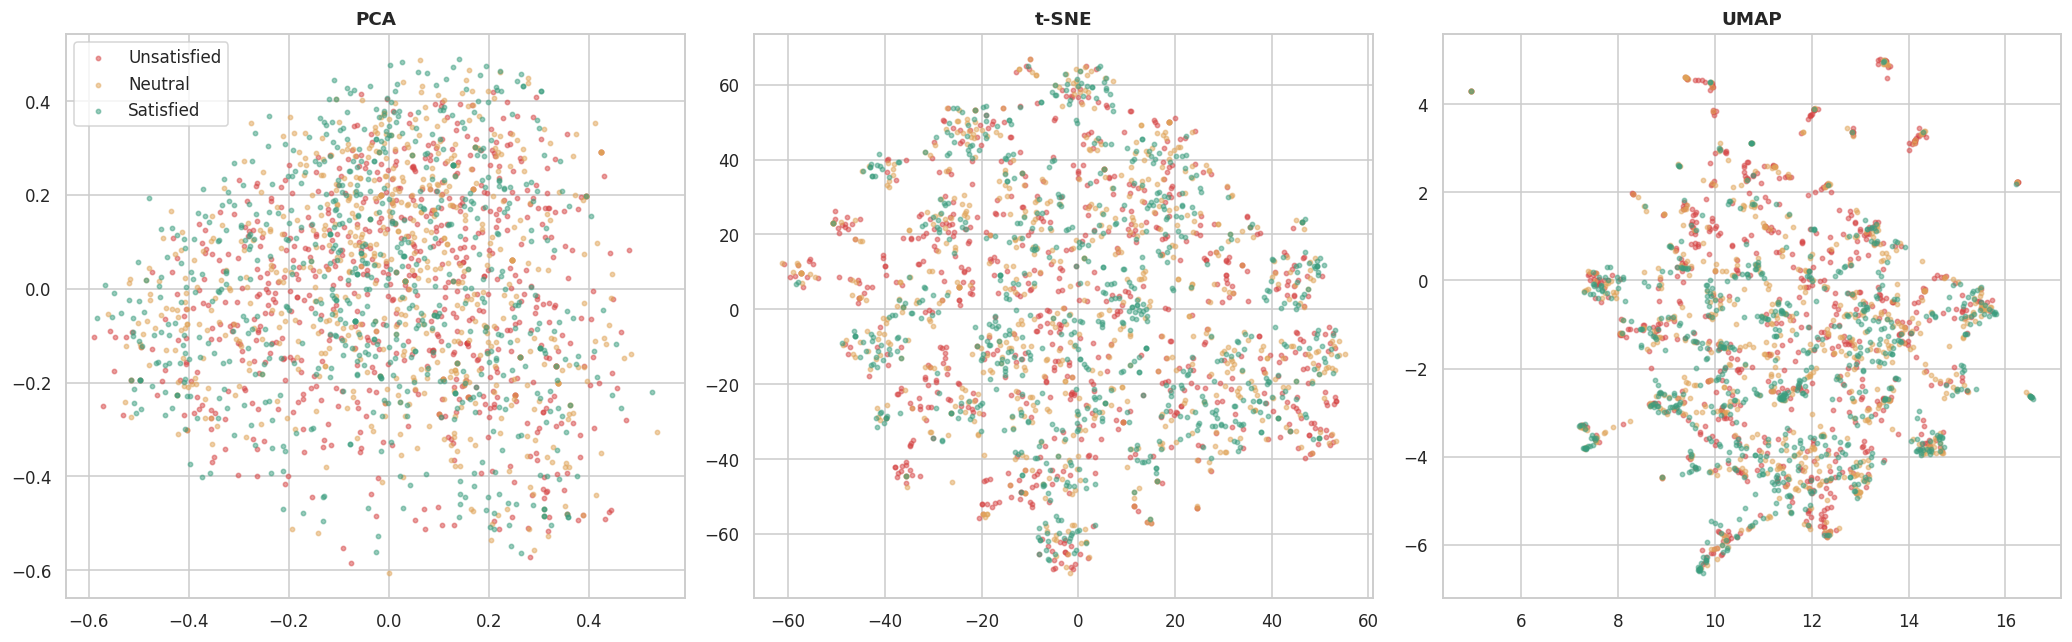

In [12]:
# ============================================================================
# 11.1 · TF-IDF representation
# ============================================================================
print("🔠 Fitting TF-IDF ...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                        min_df=3, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df["clean_text"])
print("   TF-IDF matrix:", X_tfidf.shape)

# ============================================================================
# 11.2 · Sentence-Transformer embeddings (cached, batched, GPU-aware)
# ============================================================================
EMB_PATH = CONFIG.paths["embeddings"] / f"minilm_{len(df)}.npy"
EMBEDDER = None

@timer
def compute_embeddings(texts: List[str], cfg: Config) -> np.ndarray:
    """Compute (or load cached) sentence embeddings; fall back to SVD of TF-IDF."""
    global EMBEDDER
    if EMB_PATH.exists():
        logger.info(f"Loading cached embeddings from {EMB_PATH}")
        return np.load(EMB_PATH)
    try:
        from sentence_transformers import SentenceTransformer
        EMBEDDER = SentenceTransformer(cfg.embedding_model, device=DEVICE)
        emb = EMBEDDER.encode(texts, batch_size=64, show_progress_bar=True,
                              convert_to_numpy=True, normalize_embeddings=True)
        np.save(EMB_PATH, emb)
        return emb
    except Exception as e:
        logger.warning(f"Transformer embeddings failed ({e}); using TruncatedSVD fallback.")
        svd = TruncatedSVD(n_components=256, random_state=cfg.seed)
        emb = svd.fit_transform(X_tfidf).astype(np.float32)
        np.save(EMB_PATH, emb)
        return emb

if CONFIG.transformer_embeddings_enabled:
    X_emb = compute_embeddings(df["review_text"].astype(str).tolist(), CONFIG)
else:
    X_emb = TruncatedSVD(256, random_state=CONFIG.seed).fit_transform(X_tfidf).astype(np.float32)
print("   Embedding matrix:", X_emb.shape)

# ensure embedder is available later (for search / RAG) even if loaded from cache
if EMBEDDER is None:
    try:
        from sentence_transformers import SentenceTransformer
        EMBEDDER = SentenceTransformer(CONFIG.embedding_model, device=DEVICE)
    except Exception as e:
        logger.warning(f"Could not load embedder for later use: {e}")

# ============================================================================
# 11.3 · Dimensionality-reduction visualisation (PCA / t-SNE / UMAP)
# ============================================================================
@safe(label="dimreduction_plot")
def plot_dimreduction(X_emb: np.ndarray, labels: pd.Series, cfg: Config):
    n = min(cfg.tsne_sample, X_emb.shape[0])
    idx = np.random.RandomState(cfg.seed).choice(X_emb.shape[0], n, replace=False)
    Xs, ys = X_emb[idx], labels.iloc[idx].astype(str).values
    fig, axes = plt.subplots(1, 3, figsize=(19, 6))

    pca = PCA(n_components=2, random_state=cfg.seed).fit_transform(Xs)
    for cls in CLASS_ORDER:
        m = ys == cls
        axes[0].scatter(pca[m, 0], pca[m, 1], s=8, alpha=.5,
                        c=PALETTE[cls], label=cls)
    axes[0].set_title("PCA", fontweight="bold"); axes[0].legend()

    try:
        ts = TSNE(n_components=2, random_state=cfg.seed, init="pca",
                  perplexity=30).fit_transform(Xs)
        for cls in CLASS_ORDER:
            m = ys == cls
            axes[1].scatter(ts[m, 0], ts[m, 1], s=8, alpha=.5,
                            c=PALETTE[cls], label=cls)
        axes[1].set_title("t-SNE", fontweight="bold")
    except Exception as e:
        axes[1].set_title("t-SNE unavailable"); logger.warning(f"t-SNE: {e}")

    if cfg.umap_enabled:
        try:
            import umap
            um = umap.UMAP(n_components=2, random_state=cfg.seed).fit_transform(Xs)
            for cls in CLASS_ORDER:
                m = ys == cls
                axes[2].scatter(um[m, 0], um[m, 1], s=8, alpha=.5,
                                c=PALETTE[cls], label=cls)
            axes[2].set_title("UMAP", fontweight="bold")
        except Exception as e:
            axes[2].set_title("UMAP unavailable"); logger.warning(f"UMAP: {e}")
    plt.tight_layout(); savefig(fig, "embedding_projection.png"); plt.show()

plot_dimreduction(X_emb, df["satisfaction"], CONFIG)

# 12 · Feature Assembly & Train/Validation/Test Split

We assemble the modelling matrices. Structured features are standardised; the multimodal matrix concatenates
standardised structured features with dense embeddings. Splits are stratified on the satisfaction class and
shared across every model for a fair comparison.

In [13]:
# ============================================================================
# 12.1 · Assemble matrices & stratified splits
# ============================================================================
# structured matrix
X_struct = df[STRUCTURED_FEATURES].fillna(0.0).values.astype(np.float32)
scaler = StandardScaler().fit(X_struct)
X_struct_s = scaler.transform(X_struct)

# multimodal = structured + embeddings
X_multi = np.hstack([X_struct_s, X_emb]).astype(np.float32)

# targets
y_class = df["satisfaction"].astype(str).values
class_encoder = LabelEncoder().fit(CLASS_ORDER)
y_class_enc = class_encoder.transform(y_class)
# LabelEncoder sorts classes alphabetically -> keep the encoded order explicit
ENC_CLASSES = list(class_encoder.classes_)          # order matching integer labels
SAT_IDX = int(class_encoder.transform(["Satisfied"])[0])
y_reg = df["review_score"].values.astype(np.float32)

# shared stratified split (train / test), then carve val out of train
idx_all = np.arange(len(df))
idx_train, idx_test = train_test_split(
    idx_all, test_size=CONFIG.test_size, random_state=CONFIG.seed, stratify=y_class_enc)
idx_train, idx_val = train_test_split(
    idx_train, test_size=CONFIG.val_size / (1 - CONFIG.test_size),
    random_state=CONFIG.seed, stratify=y_class_enc[idx_train])

def split_matrix(X):
    return X[idx_train], X[idx_val], X[idx_test]

Xs_tr, Xs_va, Xs_te = split_matrix(X_struct_s)          # structured
Xm_tr, Xm_va, Xm_te = split_matrix(X_multi)             # multimodal
Xt_tr = X_tfidf[idx_train]; Xt_va = X_tfidf[idx_val]; Xt_te = X_tfidf[idx_test]  # tfidf
yc_tr, yc_va, yc_te = y_class_enc[idx_train], y_class_enc[idx_val], y_class_enc[idx_test]
yr_tr, yr_va, yr_te = y_reg[idx_train], y_reg[idx_val], y_reg[idx_test]

print(f"📦 Splits — train={len(idx_train):,}  val={len(idx_val):,}  test={len(idx_test):,}")
print(f"   structured dim={Xs_tr.shape[1]}  multimodal dim={Xm_tr.shape[1]}  "
      f"tfidf dim={Xt_tr.shape[1]}")

📦 Splits — train=9,985  val=1,427  test=2,853
   structured dim=39  multimodal dim=423  tfidf dim=2182


# 13 · Classification Model Zoo

We train a broad set of satisfaction classifiers and compare them on the held-out test set:
Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost, an MLP, and a **multimodal hybrid** neural
network (structured features + sentence embeddings). Every model uses the shared split. Results are collected
into a leaderboard and the best model (by macro-F1) is selected.

In [14]:
# ============================================================================
# 13.1 · Unified evaluation helper for classifiers
# ============================================================================
CLASSIFICATION_RESULTS: Dict[str, Dict[str, Any]] = {}
CLF_MODELS: Dict[str, Any] = {}

def eval_classifier(name: str, model, X_te, y_te, proba=None) -> Dict[str, Any]:
    """Compute a standard metric bundle for a fitted classifier."""
    preds = model.predict(X_te)          # wrappers ignore X_te and return cached preds
    if proba is None and hasattr(model, "predict_proba"):
        try: proba = model.predict_proba(X_te)
        except Exception: proba = None
    res = {
        "accuracy": accuracy_score(y_te, preds),
        "precision_macro": precision_score(y_te, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(y_te, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(y_te, preds, average="macro", zero_division=0),
    }
    if proba is not None:
        try:
            res["roc_auc_ovr"] = roc_auc_score(y_te, proba, multi_class="ovr", average="macro")
        except Exception:
            res["roc_auc_ovr"] = np.nan
    else:
        res["roc_auc_ovr"] = np.nan
    res["_preds"] = preds
    res["_proba"] = proba
    return res

def register_clf(name: str, model, X_te, y_te):
    res = eval_classifier(name, model, X_te, y_te)
    CLASSIFICATION_RESULTS[name] = res
    CLF_MODELS[name] = model
    logger.info(f"[CLF] {name:22s} acc={res['accuracy']:.3f} "
                f"f1={res['f1_macro']:.3f} auc={res['roc_auc_ovr']:.3f}")

# ============================================================================
# 13.2 · Classic + boosting models (on structured features)
# ============================================================================
print("🏋️  Training classification models ...")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced")
lr.fit(Xs_tr, yc_tr); register_clf("LogisticRegression", lr, Xs_te, yc_te)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=None, n_jobs=-1,
                            class_weight="balanced", random_state=CONFIG.seed)
rf.fit(Xs_tr, yc_tr); register_clf("RandomForest", rf, Xs_te, yc_te)

# XGBoost
@safe(label="xgb_clf")
def train_xgb():
    from xgboost import XGBClassifier
    m = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                      subsample=0.9, colsample_bytree=0.9, tree_method="hist",
                      eval_metric="mlogloss", random_state=CONFIG.seed,
                      device=("cuda" if DEVICE == "cuda" else "cpu"))
    m.fit(Xs_tr, yc_tr); return m
xgb_clf = train_xgb()
if xgb_clf is not None: register_clf("XGBoost", xgb_clf, Xs_te, yc_te)

# LightGBM
@safe(label="lgbm_clf")
def train_lgbm():
    from lightgbm import LGBMClassifier
    m = LGBMClassifier(n_estimators=400, max_depth=-1, learning_rate=0.05,
                       subsample=0.9, colsample_bytree=0.9, class_weight="balanced",
                       random_state=CONFIG.seed, verbose=-1)
    m.fit(Xs_tr, yc_tr); return m
lgbm_clf = train_lgbm()
if lgbm_clf is not None: register_clf("LightGBM", lgbm_clf, Xs_te, yc_te)

# CatBoost
@safe(label="catboost_clf")
def train_cat():
    from catboost import CatBoostClassifier
    m = CatBoostClassifier(iterations=400, depth=6, learning_rate=0.05,
                           loss_function="MultiClass", verbose=False,
                           random_seed=CONFIG.seed,
                           task_type=("GPU" if DEVICE == "cuda" else "CPU"))
    m.fit(Xs_tr, yc_tr); return m
cat_clf = train_cat()
if cat_clf is not None: register_clf("CatBoost", cat_clf, Xs_te, yc_te)

# MLP (sklearn) on structured features
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=120,
                    early_stopping=True, random_state=CONFIG.seed)
mlp.fit(Xs_tr, yc_tr); register_clf("MLP", mlp, Xs_te, yc_te)

# ============================================================================
# 13.3 · Multimodal hybrid neural net (structured + embeddings) via Torch
# ============================================================================
@safe(label="hybrid_clf")
def train_hybrid_classifier():
    if torch is None:
        return None
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

    class HybridNet(nn.Module):
        def __init__(self, n_struct, n_emb, n_cls):
            super().__init__()
            self.struct = nn.Sequential(nn.Linear(n_struct, 64), nn.ReLU(), nn.Dropout(0.3))
            self.emb = nn.Sequential(nn.Linear(n_emb, 128), nn.ReLU(), nn.Dropout(0.3))
            self.head = nn.Sequential(nn.Linear(192, 64), nn.ReLU(),
                                      nn.Dropout(0.2), nn.Linear(64, n_cls))
        def forward(self, xs, xe):
            return self.head(torch.cat([self.struct(xs), self.emb(xe)], dim=1))

    n_struct = Xs_tr.shape[1]
    dev = torch.device(DEVICE)
    model = HybridNet(n_struct, X_emb.shape[1], len(CLASS_ORDER)).to(dev)

    def to_t(a): return torch.tensor(a, dtype=torch.float32)
    Xtr = to_t(Xm_tr); ytr = torch.tensor(yc_tr, dtype=torch.long)
    ds = TensorDataset(Xtr[:, :n_struct], Xtr[:, n_struct:], ytr)
    dl = DataLoader(ds, batch_size=256, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    lossf = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(12):
        for xs, xe, yb in dl:
            xs, xe, yb = xs.to(dev), xe.to(dev), yb.to(dev)
            opt.zero_grad(); out = model(xs, xe); loss = lossf(out, yb)
            loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        Xte = to_t(Xm_te)
        logits = model(Xte[:, :n_struct].to(dev), Xte[:, n_struct:].to(dev))
        proba = torch.softmax(logits, dim=1).cpu().numpy()
    preds = proba.argmax(1)

    class _Wrap:
        _precomputed_preds = True
        def predict(self, X=None): return preds
        def predict_proba(self, X=None): return proba
    return _Wrap()

hybrid_clf = train_hybrid_classifier()
if hybrid_clf is not None:
    res = eval_classifier("HybridMultimodalNN", hybrid_clf, Xm_te, yc_te,
                          proba=hybrid_clf.predict_proba())
    CLASSIFICATION_RESULTS["HybridMultimodalNN"] = res
    CLF_MODELS["HybridMultimodalNN"] = hybrid_clf
    logger.info(f"[CLF] {'HybridMultimodalNN':22s} acc={res['accuracy']:.3f} "
                f"f1={res['f1_macro']:.3f} auc={res['roc_auc_ovr']:.3f}")

# ============================================================================
# 13.4 · Classification leaderboard
# ============================================================================
clf_board = (pd.DataFrame({k: {m: v for m, v in r.items() if not m.startswith("_")}
                           for k, r in CLASSIFICATION_RESULTS.items()}).T
             .sort_values("f1_macro", ascending=False))
BEST_CLF_NAME = clf_board.index[0]
print("\n🏆 CLASSIFICATION LEADERBOARD (sorted by macro-F1)")
print(clf_board.round(4).to_string())
print(f"\n✅ Best classifier: {BEST_CLF_NAME}")

🏋️  Training classification models ...

🏆 CLASSIFICATION LEADERBOARD (sorted by macro-F1)
                    accuracy  precision_macro  recall_macro  f1_macro  roc_auc_ovr
HybridMultimodalNN    0.6369           0.6087        0.6193    0.6104       0.8045
LightGBM              0.5983           0.5813        0.5850    0.5828       0.7756
CatBoost              0.6032           0.5678        0.5834    0.5682       0.7791
LogisticRegression    0.5875           0.5655        0.5727    0.5680       0.7653
RandomForest          0.6022           0.5680        0.5824    0.5671       0.7747
MLP                   0.5941           0.5656        0.5768    0.5663       0.7645
XGBoost               0.5903           0.5606        0.5730    0.5639       0.7691

✅ Best classifier: HybridMultimodalNN


# 14 · Regression Model Zoo

The same broad comparison for predicting the raw review score: Linear Regression, Random Forest Regressor,
XGBoost, LightGBM, CatBoost, an MLP Regressor and a multimodal hybrid regressor. Ranked by test RMSE.

In [15]:
# ============================================================================
# 14.1 · Regression training + evaluation
# ============================================================================
REGRESSION_RESULTS: Dict[str, Dict[str, Any]] = {}
REG_MODELS: Dict[str, Any] = {}

def eval_regressor(name: str, preds, y_te) -> Dict[str, Any]:
    res = {
        "MAE": mean_absolute_error(y_te, preds),
        "RMSE": math.sqrt(mean_squared_error(y_te, preds)),
        "R2": r2_score(y_te, preds),
        "_preds": preds,
    }
    return res

def register_reg(name: str, model, preds, y_te):
    res = eval_regressor(name, preds, y_te)
    REGRESSION_RESULTS[name] = res
    REG_MODELS[name] = model
    logger.info(f"[REG] {name:24s} MAE={res['MAE']:.3f} "
                f"RMSE={res['RMSE']:.3f} R2={res['R2']:.3f}")

print("🏋️  Training regression models ...")

lin = LinearRegression().fit(Xs_tr, yr_tr)
register_reg("LinearRegression", lin, lin.predict(Xs_te), yr_te)

rfr = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=CONFIG.seed)
rfr.fit(Xs_tr, yr_tr); register_reg("RandomForestReg", rfr, rfr.predict(Xs_te), yr_te)

@safe(label="xgb_reg")
def train_xgbr():
    from xgboost import XGBRegressor
    m = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                     subsample=0.9, colsample_bytree=0.9, tree_method="hist",
                     random_state=CONFIG.seed,
                     device=("cuda" if DEVICE == "cuda" else "cpu"))
    m.fit(Xs_tr, yr_tr); return m
xgbr = train_xgbr()
if xgbr is not None: register_reg("XGBoostReg", xgbr, xgbr.predict(Xs_te), yr_te)

@safe(label="lgbm_reg")
def train_lgbmr():
    from lightgbm import LGBMRegressor
    m = LGBMRegressor(n_estimators=500, learning_rate=0.05, subsample=0.9,
                      colsample_bytree=0.9, random_state=CONFIG.seed, verbose=-1)
    m.fit(Xs_tr, yr_tr); return m
lgbmr = train_lgbmr()
if lgbmr is not None: register_reg("LightGBMReg", lgbmr, lgbmr.predict(Xs_te), yr_te)

@safe(label="cat_reg")
def train_catr():
    from catboost import CatBoostRegressor
    m = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05, verbose=False,
                          random_seed=CONFIG.seed,
                          task_type=("GPU" if DEVICE == "cuda" else "CPU"))
    m.fit(Xs_tr, yr_tr); return m
catr = train_catr()
if catr is not None: register_reg("CatBoostReg", catr, catr.predict(Xs_te), yr_te)

mlpr = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=150,
                    early_stopping=True, random_state=CONFIG.seed)
mlpr.fit(Xs_tr, yr_tr); register_reg("MLPReg", mlpr, mlpr.predict(Xs_te), yr_te)

# multimodal hybrid regressor
@safe(label="hybrid_reg")
def train_hybrid_regressor():
    if torch is None: return None, None
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    n_struct = Xs_tr.shape[1]; dev = torch.device(DEVICE)

    class HybridReg(nn.Module):
        def __init__(self, ns, ne):
            super().__init__()
            self.s = nn.Sequential(nn.Linear(ns, 64), nn.ReLU(), nn.Dropout(0.3))
            self.e = nn.Sequential(nn.Linear(ne, 128), nn.ReLU(), nn.Dropout(0.3))
            self.h = nn.Sequential(nn.Linear(192, 64), nn.ReLU(), nn.Linear(64, 1))
        def forward(self, xs, xe):
            return self.h(torch.cat([self.s(xs), self.e(xe)], 1)).squeeze(-1)

    model = HybridReg(n_struct, X_emb.shape[1]).to(dev)
    Xtr = torch.tensor(Xm_tr, dtype=torch.float32)
    ytr = torch.tensor(yr_tr, dtype=torch.float32)
    dl = DataLoader(TensorDataset(Xtr[:, :n_struct], Xtr[:, n_struct:], ytr),
                    batch_size=256, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3); lossf = nn.MSELoss()
    model.train()
    for _ in range(15):
        for xs, xe, yb in dl:
            xs, xe, yb = xs.to(dev), xe.to(dev), yb.to(dev)
            opt.zero_grad(); loss = lossf(model(xs, xe), yb); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        Xte = torch.tensor(Xm_te, dtype=torch.float32)
        preds = model(Xte[:, :n_struct].to(dev),
                      Xte[:, n_struct:].to(dev)).cpu().numpy()
    return model, preds

hybrid_reg, hybrid_reg_preds = train_hybrid_regressor()
if hybrid_reg is not None:
    register_reg("HybridMultimodalReg", hybrid_reg, hybrid_reg_preds, yr_te)

reg_board = (pd.DataFrame({k: {m: v for m, v in r.items() if not m.startswith("_")}
                           for k, r in REGRESSION_RESULTS.items()}).T
             .sort_values("RMSE"))
BEST_REG_NAME = reg_board.index[0]
print("\n🏆 REGRESSION LEADERBOARD (sorted by RMSE)")
print(reg_board.round(4).to_string())
print(f"\n✅ Best regressor: {BEST_REG_NAME}")

🏋️  Training regression models ...

🏆 REGRESSION LEADERBOARD (sorted by RMSE)
                        MAE    RMSE      R2
HybridMultimodalReg  0.9557  1.1901  0.5170
CatBoostReg          0.9757  1.2209  0.4917
LightGBMReg          0.9849  1.2323  0.4821
XGBoostReg           0.9844  1.2332  0.4813
RandomForestReg      0.9886  1.2357  0.4792
LinearRegression     1.0162  1.2633  0.4557
MLPReg               1.0427  1.3020  0.4218

✅ Best regressor: HybridMultimodalReg


# 15 · Hyperparameter Optimization with Optuna (pruning enabled)

We tune the strongest gradient-boosting classifier with Optuna's TPE sampler and a **MedianPruner**. The
search space covers learning rate, depth, number of estimators, subsampling and regularisation. The best
trial is retrained on the full training set and added to the leaderboard if it improves macro-F1.

🔧 Running Optuna hyperparameter optimization ...


  0%|          | 0/20 [00:00<?, ?it/s]

   Best val macro-F1: 0.5999
   Best params: {'n_estimators': 600, 'learning_rate': 0.021985936091282434, 'max_depth': 12, 'num_leaves': 15, 'subsample': 0.8665528747638527, 'colsample_bytree': 0.6035928668790913, 'reg_lambda': 1.4062592892757726}

🏆 UPDATED CLASSIFICATION LEADERBOARD
                    accuracy  precision_macro  recall_macro  f1_macro  roc_auc_ovr
HybridMultimodalNN    0.6369           0.6087        0.6193    0.6104       0.8045
Optuna-Tuned          0.6022           0.5881        0.5897    0.5888       0.7804
LightGBM              0.5983           0.5813        0.5850    0.5828       0.7756
CatBoost              0.6032           0.5678        0.5834    0.5682       0.7791
LogisticRegression    0.5875           0.5655        0.5727    0.5680       0.7653
RandomForest          0.6022           0.5680        0.5824    0.5671       0.7747
MLP                   0.5941           0.5656        0.5768    0.5663       0.7645
XGBoost               0.5903           0.5606     

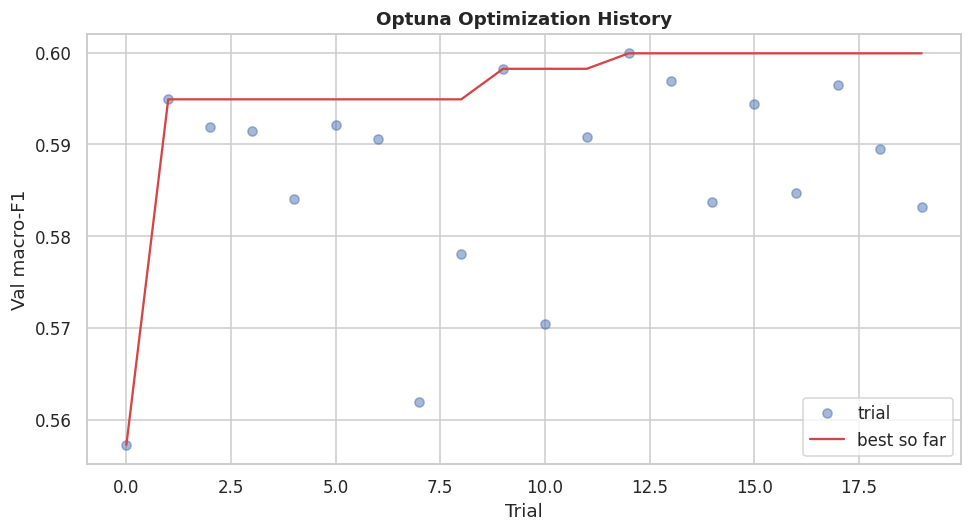

In [16]:
# ============================================================================
# 15.1 · Optuna study for a LightGBM/XGBoost classifier
# ============================================================================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_STUDY = None
TUNED_MODEL = None

@safe(default=None, label="optuna_study")
def run_optuna(cfg: Config):
    from sklearn.model_selection import cross_val_score
    try:
        from lightgbm import LGBMClassifier
        backend = "lgbm"
    except Exception:
        from sklearn.ensemble import GradientBoostingClassifier
        backend = "gb"

    def objective(trial: "optuna.Trial") -> float:
        if backend == "lgbm":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
                "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
                "max_depth": trial.suggest_int("max_depth", 3, 12),
                "num_leaves": trial.suggest_int("num_leaves", 15, 128),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
                "random_state": cfg.seed, "verbose": -1, "class_weight": "balanced",
            }
            model = LGBMClassifier(**params)
        else:
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=25),
                "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
                "max_depth": trial.suggest_int("max_depth", 2, 6),
                "random_state": cfg.seed,
            }
            model = GradientBoostingClassifier(**params)
        # validation-set score with pruning support
        model.fit(Xs_tr, yc_tr)
        preds = model.predict(Xs_va)
        score = f1_score(yc_va, preds, average="macro")
        trial.report(score, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()
        return score

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=cfg.seed),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=0))
    study.optimize(objective, n_trials=cfg.optuna_trials,
                   timeout=cfg.optuna_timeout, show_progress_bar=True)
    return study, backend

print("🔧 Running Optuna hyperparameter optimization ...")
_res = run_optuna(CONFIG)
if _res is not None:
    OPTUNA_STUDY, _backend = _res
    print(f"   Best val macro-F1: {OPTUNA_STUDY.best_value:.4f}")
    print(f"   Best params: {OPTUNA_STUDY.best_params}")

    # retrain best model on train and evaluate on test
    @safe(label="retrain_tuned")
    def retrain_best():
        if _backend == "lgbm":
            from lightgbm import LGBMClassifier
            m = LGBMClassifier(**OPTUNA_STUDY.best_params, verbose=-1,
                               class_weight="balanced", random_state=CONFIG.seed)
        else:
            from sklearn.ensemble import GradientBoostingClassifier
            m = GradientBoostingClassifier(**OPTUNA_STUDY.best_params,
                                           random_state=CONFIG.seed)
        m.fit(Xs_tr, yc_tr)
        return m
    TUNED_MODEL = retrain_best()
    if TUNED_MODEL is not None:
        register_clf("Optuna-Tuned", TUNED_MODEL, Xs_te, yc_te)
        # refresh leaderboard + best
        clf_board = (pd.DataFrame({k: {m: v for m, v in r.items()
                     if not m.startswith("_")} for k, r in CLASSIFICATION_RESULTS.items()}).T
                     .sort_values("f1_macro", ascending=False))
        BEST_CLF_NAME = clf_board.index[0]
        print("\n🏆 UPDATED CLASSIFICATION LEADERBOARD")
        print(clf_board.round(4).to_string())
        print(f"\n✅ Best classifier now: {BEST_CLF_NAME}")

# optimization-history plot
@safe(label="optuna_plot")
def plot_optuna(study):
    if study is None: return
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(vals)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(range(len(vals)), vals, "o", alpha=.5, label="trial")
    ax.plot(range(len(best_so_far)), best_so_far, "-", color="#d64545", label="best so far")
    ax.set_xlabel("Trial"); ax.set_ylabel("Val macro-F1")
    ax.set_title("Optuna Optimization History", fontweight="bold"); ax.legend()
    plt.tight_layout(); savefig(fig, "optuna_history.png"); plt.show()
plot_optuna(OPTUNA_STUDY)

# 16 · Model Evaluation (classification + regression diagnostics)

Full diagnostic suite for the best models: confusion matrix, per-class report, ROC & PR curves, calibration
curve for the classifier; residual and prediction-error plots for the regressor.

📋 Classification report — HybridMultimodalNN

              precision    recall  f1-score   support

     Neutral       0.44      0.33      0.38       835
   Satisfied       0.72      0.77      0.74      1004
 Unsatisfied       0.67      0.76      0.71      1014

    accuracy                           0.64      2853
   macro avg       0.61      0.62      0.61      2853
weighted avg       0.62      0.64      0.62      2853



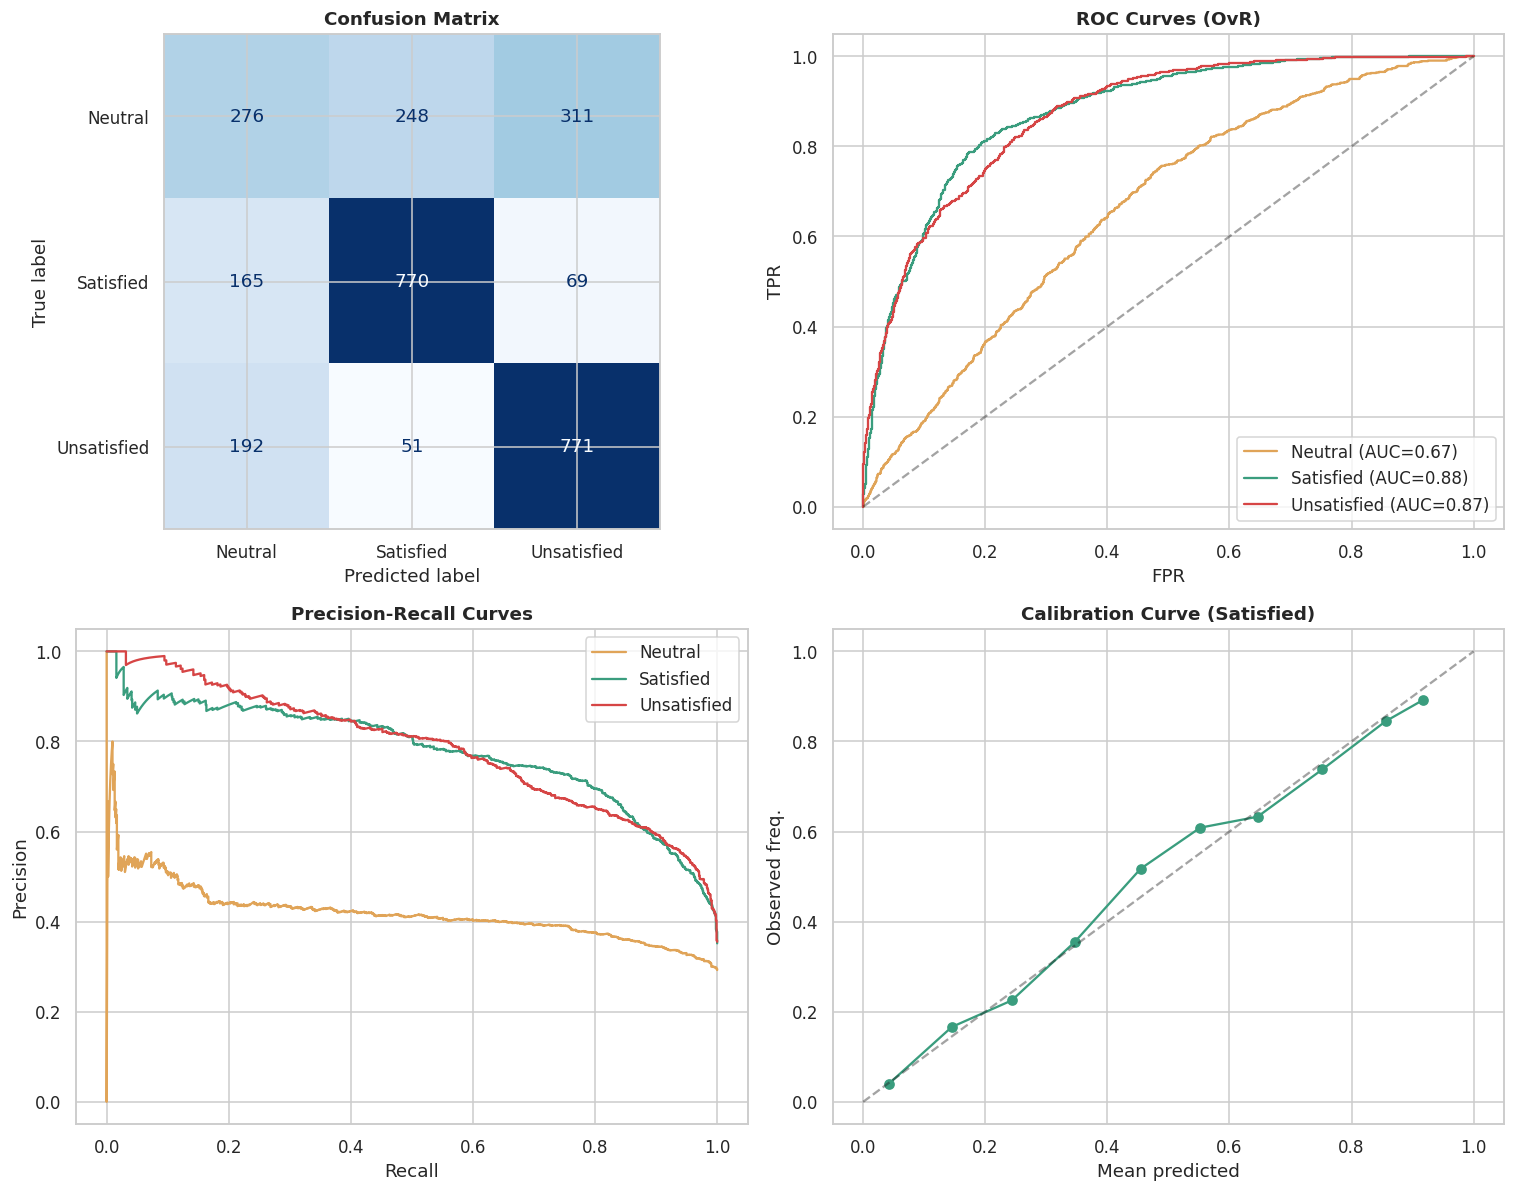

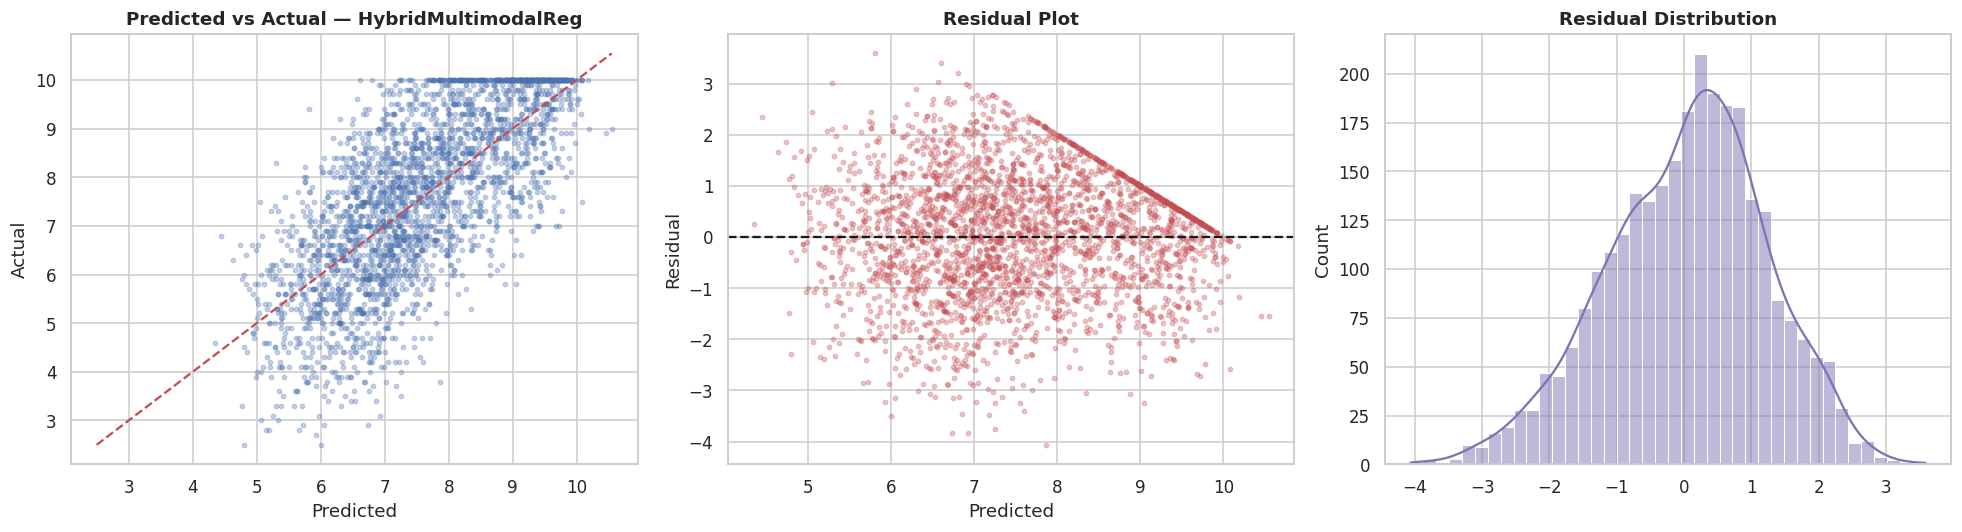

📈 Best regressor HybridMultimodalReg: MAE=0.956  RMSE=1.190  R²=0.517


In [17]:
# ============================================================================
# 16.1 · Classification diagnostics for the best model
# ============================================================================
from sklearn.preprocessing import label_binarize

best_clf_res = CLASSIFICATION_RESULTS[BEST_CLF_NAME]
best_preds = best_clf_res["_preds"]
best_proba = best_clf_res["_proba"]

print(f"📋 Classification report — {BEST_CLF_NAME}\n")
print(classification_report(yc_te, best_preds, target_names=ENC_CLASSES, zero_division=0))

@safe(label="clf_diagnostics")
def clf_diagnostics(y_te, preds, proba):
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    # confusion matrix
    cm = confusion_matrix(y_te, preds)
    ConfusionMatrixDisplay(cm, display_labels=ENC_CLASSES).plot(
        ax=axes[0, 0], cmap="Blues", colorbar=False)
    axes[0, 0].set_title("Confusion Matrix", fontweight="bold")

    if proba is not None:
        y_bin = label_binarize(y_te, classes=[0, 1, 2])
        # ROC per class (column i corresponds to ENC_CLASSES[i])
        for i, cls in enumerate(ENC_CLASSES):
            fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
            axes[0, 1].plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})",
                            color=PALETTE.get(cls, None))
        axes[0, 1].plot([0, 1], [0, 1], "k--", alpha=.4)
        axes[0, 1].set_title("ROC Curves (OvR)", fontweight="bold")
        axes[0, 1].set_xlabel("FPR"); axes[0, 1].set_ylabel("TPR"); axes[0, 1].legend()

        # PR per class
        for i, cls in enumerate(ENC_CLASSES):
            pr, rc, _ = precision_recall_curve(y_bin[:, i], proba[:, i])
            axes[1, 0].plot(rc, pr, label=cls, color=PALETTE.get(cls, None))
        axes[1, 0].set_title("Precision-Recall Curves", fontweight="bold")
        axes[1, 0].set_xlabel("Recall"); axes[1, 0].set_ylabel("Precision"); axes[1, 0].legend()

        # calibration for "Satisfied"
        pos = SAT_IDX
        frac, mean_pred = calibration_curve((y_te == pos).astype(int),
                                            proba[:, pos], n_bins=10)
        axes[1, 1].plot(mean_pred, frac, "o-", color="#3a9d7e")
        axes[1, 1].plot([0, 1], [0, 1], "k--", alpha=.4)
        axes[1, 1].set_title("Calibration Curve (Satisfied)", fontweight="bold")
        axes[1, 1].set_xlabel("Mean predicted"); axes[1, 1].set_ylabel("Observed freq.")
    plt.tight_layout(); savefig(fig, "classification_diagnostics.png"); plt.show()

clf_diagnostics(yc_te, best_preds, best_proba)

# ============================================================================
# 16.2 · Regression diagnostics for the best regressor
# ============================================================================
best_reg_res = REGRESSION_RESULTS[BEST_REG_NAME]
best_reg_preds = best_reg_res["_preds"]

@safe(label="reg_diagnostics")
def reg_diagnostics(y_te, preds):
    resid = y_te - preds
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].scatter(preds, y_te, s=8, alpha=.3, color="#4c72b0")
    lims = [min(y_te.min(), preds.min()), max(y_te.max(), preds.max())]
    axes[0].plot(lims, lims, "r--")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
    axes[0].set_title(f"Predicted vs Actual — {BEST_REG_NAME}", fontweight="bold")

    axes[1].scatter(preds, resid, s=8, alpha=.3, color="#c44e52")
    axes[1].axhline(0, color="k", ls="--")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
    axes[1].set_title("Residual Plot", fontweight="bold")

    sns.histplot(resid, bins=40, kde=True, color="#8172b3", ax=axes[2])
    axes[2].set_title("Residual Distribution", fontweight="bold")
    plt.tight_layout(); savefig(fig, "regression_diagnostics.png"); plt.show()

reg_diagnostics(yr_te, best_reg_preds)
print(f"📈 Best regressor {BEST_REG_NAME}: "
      f"MAE={best_reg_res['MAE']:.3f}  RMSE={best_reg_res['RMSE']:.3f}  "
      f"R²={best_reg_res['R2']:.3f}")

# 17 · Explainable AI with SHAP

We explain the best tree-based classifier with SHAP: a global summary (beeswarm + bar importance), a
dependence plot for the top feature, and a local waterfall/force explanation for a single review. SHAP values
are cached for the final report.

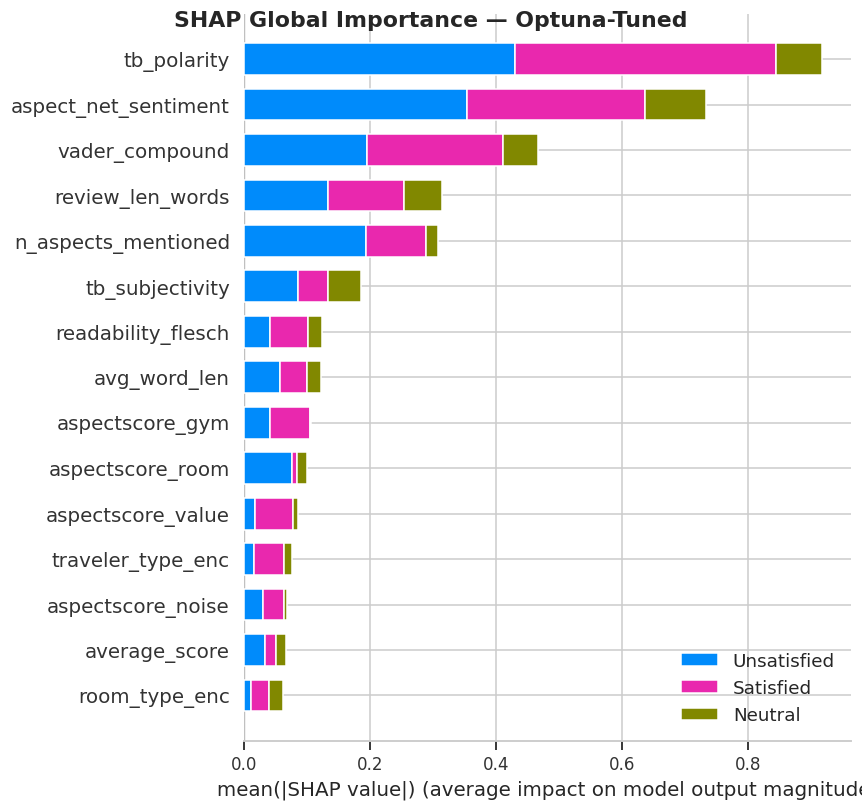

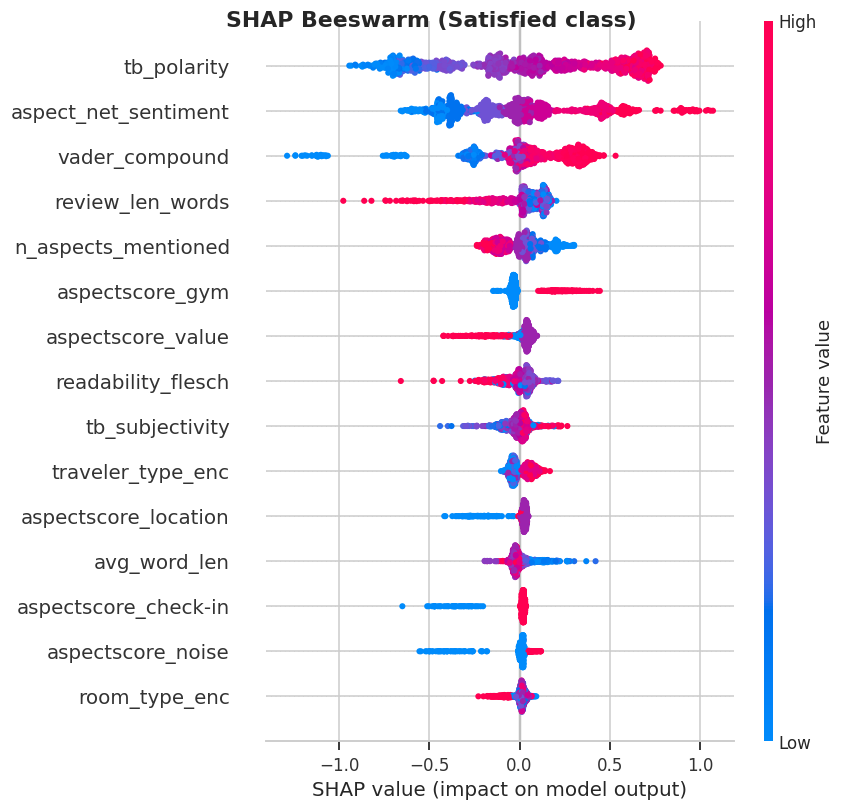

<Figure size 704x528 with 0 Axes>

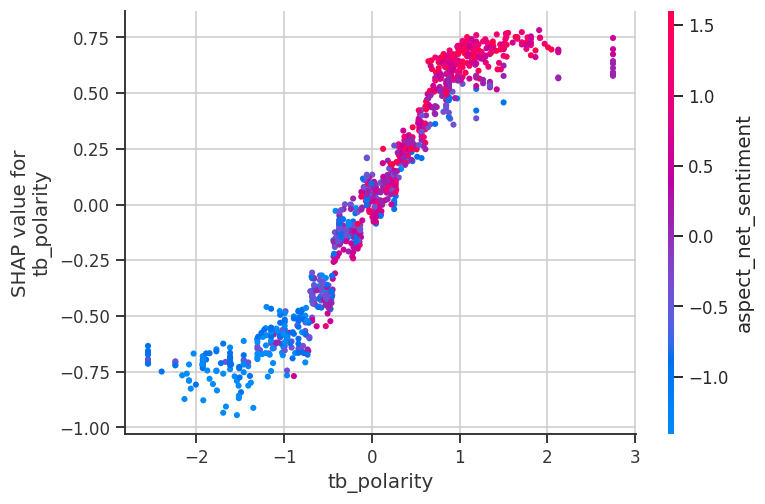

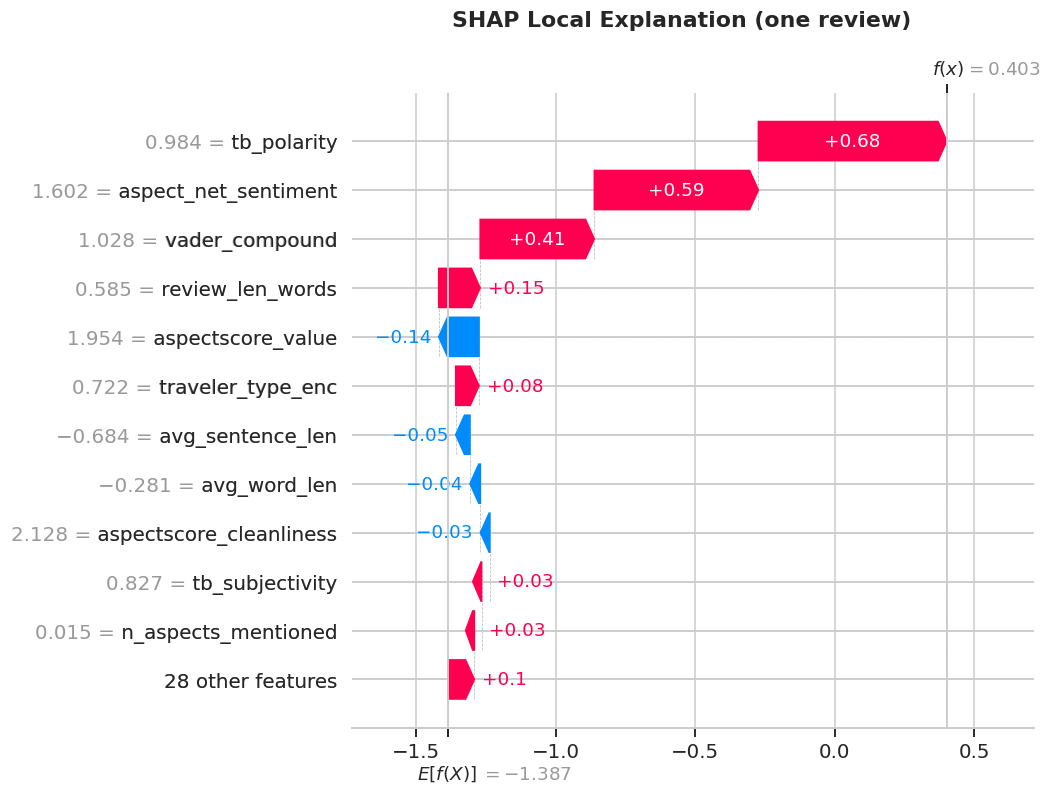

✅ SHAP explanations generated and saved.


In [18]:
# ============================================================================
# 17.1 · SHAP explanations (global + local), robust to SHAP output shapes
# ============================================================================
import shap

SHAP_VALUES = None
SHAP_EXPLAINER = None

def _class_shap(sv, idx: int):
    """Extract the SHAP matrix (n_samples, n_features) for one class, handling:
       - list of per-class arrays  -> sv[idx]
       - 3D ndarray (n, feat, cls) -> sv[:, :, idx]
       - 2D ndarray (binary/reg)   -> sv
    """
    if isinstance(sv, list):
        return sv[min(idx, len(sv) - 1)]
    sv = np.asarray(sv)
    if sv.ndim == 3:
        return sv[:, :, min(idx, sv.shape[2] - 1)]
    return sv

def _as_class_list(sv):
    """Return a list of per-class SHAP matrices for multiclass summary plots."""
    if isinstance(sv, list):
        return sv
    sv = np.asarray(sv)
    if sv.ndim == 3:
        return [sv[:, :, i] for i in range(sv.shape[2])]
    return sv

@safe(default=None, label="shap_explain")
def explain_with_shap(cfg: Config):
    tree_candidates = ["Optuna-Tuned", "LightGBM", "XGBoost", "CatBoost", "RandomForest"]
    model, mname = None, None
    for name in tree_candidates:
        if name in CLF_MODELS:
            model, mname = CLF_MODELS[name], name
            break
    if model is None:
        model, mname = rf, "RandomForest"

    bg_n = min(1000, Xs_te.shape[0])
    idx = np.random.RandomState(cfg.seed).choice(Xs_te.shape[0], bg_n, replace=False)
    X_bg = Xs_te[idx]
    feat_names = STRUCTURED_FEATURES

    try:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_bg)
    except Exception as e:
        logger.warning(f"TreeExplainer failed ({e}); using generic Explainer.")
        explainer = shap.Explainer(model.predict, X_bg)
        sv = explainer(X_bg).values

    # ---- global importance (bar) — multiclass aware --------------------
    plt.figure()
    shap.summary_plot(_as_class_list(sv), X_bg, feature_names=feat_names,
                      plot_type="bar", show=False, max_display=15,
                      class_names=ENC_CLASSES)
    fig = plt.gcf(); fig.suptitle(f"SHAP Global Importance — {mname}", fontweight="bold")
    savefig(fig, "shap_global_bar.png"); plt.show()

    # ---- beeswarm for the Satisfied class ------------------------------
    try:
        sv_cls = _class_shap(sv, SAT_IDX)
        plt.figure()
        shap.summary_plot(sv_cls, X_bg, feature_names=feat_names, show=False, max_display=15)
        fig = plt.gcf(); fig.suptitle("SHAP Beeswarm (Satisfied class)", fontweight="bold")
        savefig(fig, "shap_beeswarm.png"); plt.show()
    except Exception as e:
        logger.warning(f"Beeswarm failed: {e}")

    # ---- dependence plot for the top feature ---------------------------
    try:
        sv_cls = _class_shap(sv, SAT_IDX)
        top_idx = int(np.abs(sv_cls).mean(0).argmax())
        plt.figure()
        shap.dependence_plot(top_idx, sv_cls, X_bg, feature_names=feat_names, show=False)
        fig = plt.gcf(); savefig(fig, "shap_dependence.png"); plt.show()
    except Exception as e:
        logger.warning(f"Dependence plot failed: {e}")

    return explainer, sv, mname, feat_names, X_bg

_shap_out = explain_with_shap(CONFIG)
if _shap_out is not None:
    SHAP_EXPLAINER, SHAP_VALUES, SHAP_MODEL_NAME, SHAP_FEATURES, SHAP_X = _shap_out

    # ---- local waterfall for a single instance -------------------------
    @safe(label="shap_local")
    def shap_local():
        i = 0
        sv_cls = _class_shap(SHAP_VALUES, SAT_IDX)      # (n_samples, n_features)
        base = SHAP_EXPLAINER.expected_value
        if isinstance(base, (list, np.ndarray)) and np.ndim(base) >= 1:
            base_cls = float(np.asarray(base).ravel()[min(SAT_IDX,
                             np.asarray(base).size - 1)])
        else:
            base_cls = float(base)
        expl = shap.Explanation(values=sv_cls[i], base_values=base_cls,
                                data=SHAP_X[i], feature_names=SHAP_FEATURES)
        plt.figure()
        shap.plots.waterfall(expl, max_display=12, show=False)
        fig = plt.gcf(); fig.suptitle("SHAP Local Explanation (one review)", fontweight="bold")
        savefig(fig, "shap_waterfall.png"); plt.show()
    shap_local()
    print("✅ SHAP explanations generated and saved.")

# 18 · Topic Modeling (BERTopic) — automatic complaint discovery

BERTopic clusters negative-review embeddings into interpretable complaint themes. If BERTopic is unavailable,
we fall back to KMeans over the sentence embeddings with c-TF-IDF-style keyword extraction so complaint
categories are always produced.

In [19]:
# ============================================================================
# 18.1 · Topic modeling over negative reviews
# ============================================================================
TOPIC_MODEL = None
TOPIC_INFO = None

# focus on negative reviews for complaint discovery
neg_mask = df["negative_review"].astype(str).str.replace("No Negative", "").str.len() > 8
neg_docs = df.loc[neg_mask, "negative_review"].astype(str).tolist()
neg_docs = neg_docs[:6000] if len(neg_docs) > 6000 else neg_docs

@safe(default=None, label="bertopic")
def run_bertopic(docs: List[str], cfg: Config):
    if not cfg.bertopic_enabled or len(docs) < 50:
        return None
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    emb_model = EMBEDDER or SentenceTransformer(cfg.embedding_model, device=DEVICE)
    topic_model = BERTopic(embedding_model=emb_model, min_topic_size=25,
                           nr_topics="auto", calculate_probabilities=False,
                           verbose=False)
    topics, _ = topic_model.fit_transform(docs)
    return topic_model

TOPIC_MODEL = run_bertopic(neg_docs, CONFIG)

if TOPIC_MODEL is not None:
    TOPIC_INFO = TOPIC_MODEL.get_topic_info()
    print("🧵 BERTopic discovered complaint topics:")
    print(TOPIC_INFO.head(10)[["Topic", "Count", "Name"]].to_string(index=False))
    COMPLAINT_TOPICS = []
    for t in TOPIC_INFO["Topic"].head(8):
        if t == -1: continue
        words = ", ".join(w for w, _ in TOPIC_MODEL.get_topic(t)[:6])
        COMPLAINT_TOPICS.append({"topic": int(t), "keywords": words})
else:
    # ---- KMeans fallback --------------------------------------------------
    logger.warning("BERTopic unavailable — using KMeans keyword fallback.")
    from sklearn.cluster import KMeans
    COMPLAINT_TOPICS = []
    try:
        neg_idx = df.index[neg_mask][:6000]
        emb_neg = X_emb[df.index.get_indexer(neg_idx)]
        k = 8
        km = KMeans(n_clusters=k, random_state=CONFIG.seed, n_init=10).fit(emb_neg)
        cv = CountVectorizer(stop_words="english", max_features=3000, ngram_range=(1, 2))
        counts = cv.fit_transform(df.loc[neg_idx, "negative_review"].astype(str))
        vocab = np.array(cv.get_feature_names_out())
        for c in range(k):
            m = km.labels_ == c
            if m.sum() == 0: continue
            freqs = np.asarray(counts[m].sum(axis=0)).ravel()
            top = vocab[freqs.argsort()[::-1][:6]]
            COMPLAINT_TOPICS.append({"topic": c, "keywords": ", ".join(top)})
        TOPIC_INFO = pd.DataFrame(COMPLAINT_TOPICS)
        print("🧵 KMeans complaint clusters:")
        for t in COMPLAINT_TOPICS:
            print(f"   Cluster {t['topic']}: {t['keywords']}")
    except Exception as e:
        logger.warning(f"KMeans fallback failed: {e}")
        COMPLAINT_TOPICS = []

🧵 BERTopic discovered complaint topics:
 Topic  Count                              Name
    -1    628    -1_cold_pool_difficult_parking
     0   3956               0_room_was_cold_and
     1    756   1_wifi_dropping_constantly_kept
     2    139 2_overpriced_food_tasteless_value
     3     68  3_sheets_carpets_stained_unclean
     4     67           4_hear_could_walls_thin
     5     62             5_not_money_worth_the
     6     60           6_rude_unhelpful_staff_
     7     57     7_by_ignored_customer_service
     8     45           8_restaurant_meals_bad_


# 19 · Review Summarization (open-source transformer)

An open-source abstractive summarizer (`distilbart-cnn`) condenses the pooled reviews of a hotel into a short
executive summary. A lightweight extractive fallback (top sentences by aspect/sentiment coverage) is used if
the transformer cannot load.

In [20]:
# ============================================================================
# 19.1 · Summarization (direct seq2seq model + extractive fallback)
# ============================================================================
SUMMARIZER = None

class Seq2SeqRunner:
    """Robust seq2seq wrapper using generate() directly (avoids pipeline task issues)."""
    def __init__(self, model_name: str):
        from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
        self.tok = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        if DEVICE == "cuda":
            self.model = self.model.to("cuda")
        self.model.eval()

    def __call__(self, text: str, max_new_tokens: int = 120,
                 min_length: int = 20) -> str:
        import torch as _t
        inputs = self.tok(str(text), return_tensors="pt", truncation=True,
                          max_length=1024)
        inputs = {k: v.to(self.model.device) for k, v in inputs.items()}
        with _t.no_grad():
            out = self.model.generate(**inputs, max_new_tokens=max_new_tokens,
                                      min_length=min_length, num_beams=4,
                                      no_repeat_ngram_size=3, repetition_penalty=1.4,
                                      early_stopping=True)
        return self.tok.decode(out[0], skip_special_tokens=True).strip()

@safe(default=None, label="load_summarizer")
def load_summarizer(cfg: Config):
    if not cfg.summarization_enabled:
        return None
    return Seq2SeqRunner(cfg.summarizer_model)

SUMMARIZER = load_summarizer(CONFIG)

def extractive_summary(text: str, max_sentences: int = 3) -> str:
    """Rank sentences by |VADER| magnitude and length; return the top few."""
    sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", str(text)) if len(s.strip()) > 20]
    if not sents:
        return str(text)[:300]
    scored = sorted(sents, key=lambda s: abs(VADER.polarity_scores(s)["compound"])
                    + min(len(s), 120) / 240, reverse=True)
    return " ".join(scored[:max_sentences])

def summarize_text(text: str, max_len: int = 110) -> str:
    """Summarize text with the transformer if available, else extractive."""
    text = str(text).strip()
    if len(text) < 40:
        return text
    if SUMMARIZER is not None:
        try:
            out = SUMMARIZER(text[:1024], max_new_tokens=max_len, min_length=25)
            if out and len(out) > 10:
                return out
        except Exception as e:
            logger.warning(f"Transformer summarization failed: {e}")
    return extractive_summary(text)

def _dedupe_sentences(text: str, limit: int = 40) -> str:
    """Collapse duplicate sentences (common when pooling templated reviews)."""
    seen, out = set(), []
    for s in re.split(r"(?<=[.!?])\s+", str(text)):
        s = s.strip()
        key = s.lower()
        if s and key not in seen:
            seen.add(key); out.append(s)
        if len(out) >= limit:
            break
    return " ".join(out)

def summarize_hotel(hotel_name: str, max_reviews: int = 60) -> str:
    """Produce an executive summary of a hotel's reviews."""
    sub = df[df["hotel_name"] == hotel_name]
    if sub.empty:
        return "No reviews found for this hotel."
    pooled = _dedupe_sentences(" ".join(sub["review_text"].astype(str).head(max_reviews)))
    return summarize_text(pooled, max_len=120)

# demo on the hotel with the most reviews
_demo_hotel = df["hotel_name"].value_counts().index[0]
print(f"📝 Example summary for '{_demo_hotel}':\n")
print(summarize_hotel(_demo_hotel))

config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.22GB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.22GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=120) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


📝 Example summary for 'Imperial Palace':

Reviewer says the hotel is a great value for money . The food and facilities are immaculate and fresh throughout the buffet .


# 20 · Vector Database (FAISS) & Semantic Search

We build a persistent FAISS index over the review embeddings, store aligned metadata, and expose a semantic
search function. The index reloads from disk on subsequent runs instead of rebuilding.

In [21]:
# ============================================================================
# 20.1 · Build / load persistent FAISS index + metadata
# ============================================================================
import faiss

FAISS_INDEX_PATH = CONFIG.paths["faiss"] / "reviews.index"
FAISS_META_PATH = CONFIG.paths["faiss"] / "reviews_meta.parquet"

META_COLS = ["hotel_name", "hotel_location", "review_text", "review_score",
             "satisfaction", "trip_type", "nationality", "review_date"]

def build_faiss_index(embeddings: np.ndarray) -> "faiss.Index":
    """Build a cosine-similarity (inner-product on normalised vectors) index."""
    emb = embeddings.astype(np.float32).copy()
    faiss.normalize_L2(emb)
    index = faiss.IndexFlatIP(emb.shape[1])
    index.add(emb)
    return index

@timer
def get_faiss_index(embeddings: np.ndarray):
    """Load a persisted index if present, else build & persist it."""
    if FAISS_INDEX_PATH.exists() and FAISS_META_PATH.exists():
        try:
            idx = faiss.read_index(str(FAISS_INDEX_PATH))
            meta = pd.read_parquet(FAISS_META_PATH)
            if idx.ntotal == len(meta) == len(embeddings):
                logger.info(f"Loaded persisted FAISS index ({idx.ntotal:,} vectors).")
                return idx, meta
        except Exception as e:
            logger.warning(f"Could not reload FAISS index: {e}")
    idx = build_faiss_index(embeddings)
    faiss.write_index(idx, str(FAISS_INDEX_PATH))
    meta = df[META_COLS].reset_index(drop=True).copy()
    meta["satisfaction"] = meta["satisfaction"].astype(str)
    meta.to_parquet(FAISS_META_PATH)
    logger.info(f"Built & persisted FAISS index ({idx.ntotal:,} vectors).")
    return idx, meta

FAISS_INDEX, FAISS_META = get_faiss_index(X_emb)

def embed_query(text: str) -> np.ndarray:
    """Embed a query string with the same model used for the corpus."""
    if EMBEDDER is not None:
        v = EMBEDDER.encode([text], convert_to_numpy=True, normalize_embeddings=True)
        return v.astype(np.float32)
    # fallback: TF-IDF -> SVD projection is not aligned; use zeros-safe random proj
    v = tfidf.transform([clean_text(text)])
    return np.asarray(v.todense(), dtype=np.float32)[:, :X_emb.shape[1]]

def semantic_search(query: str, k: int = 5, hotel: Optional[str] = None) -> pd.DataFrame:
    """Return the top-k most semantically similar reviews to `query`."""
    qv = embed_query(query)
    faiss.normalize_L2(qv)
    scores, ids = FAISS_INDEX.search(qv, min(k * 6, FAISS_INDEX.ntotal))
    res = FAISS_META.iloc[ids[0]].copy()
    res["similarity"] = scores[0]
    if hotel:
        res = res[res["hotel_name"].str.contains(hotel, case=False, na=False)]
    return res.head(k)

print("🔍 Semantic search demo — query: 'dirty room and rude staff'")
_demo = semantic_search("dirty room and rude staff", k=3)
for _, r in _demo.iterrows():
    print(f"  [{r['similarity']:.2f}] ({r['review_score']:.1f}) "
          f"{r['hotel_name']}: {r['review_text'][:90]}...")

🔍 Semantic search demo — query: 'dirty room and rude staff'
  [0.84] (3.9) Garden Inn: rude unhelpful staff. room was dirty and dusty...
  [0.83] (5.4) Grand Suites: spotlessly clean room. rude unhelpful staff. chaotic check-in process...
  [0.82] (5.5) Sunset Palace: spotlessly clean room. rude unhelpful staff. unresponsive service team...


# 21 · Retrieval-Augmented Generation (RAG) Assistant

The RAG assistant answers natural-language questions over the review corpus:

1. **Retrieve** top-k reviews from FAISS (optionally filtered by hotel/country).
2. **Rerank** with a cross-encoder (`ms-marco-MiniLM`) when available.
3. **Generate** a grounded answer with an open-source LLM (`flan-t5`), falling back to an extractive answer
   built from the retrieved context if the generator can't load.

It handles questions like *"Why do guests dislike this hotel?"*, *"What do business travelers complain
about?"*, and *"Compare hotels / countries."*

In [22]:
# ============================================================================
# 21.1 · Cross-encoder reranker + open-source generator
# ============================================================================
CROSS_ENCODER = None
GENERATOR = None

@safe(default=None, label="load_cross_encoder")
def load_cross_encoder(cfg: Config):
    if not cfg.rag_enabled: return None
    from sentence_transformers import CrossEncoder
    return CrossEncoder(cfg.cross_encoder_model, device=DEVICE)

@safe(default=None, label="load_generator")
def load_generator(cfg: Config):
    if not cfg.rag_enabled: return None
    # reuse the robust Seq2SeqRunner defined in the summarization section
    return Seq2SeqRunner(cfg.generator_model)

CROSS_ENCODER = load_cross_encoder(CONFIG)
GENERATOR = load_generator(CONFIG)

def _retrieve(query: str, k: int = 8, hotel=None, country=None) -> pd.DataFrame:
    res = semantic_search(query, k=k * 3, hotel=hotel)
    if country:
        res = res[res["nationality"].str.contains(country, case=False, na=False)]
    return res.head(k * 2)

def _rerank(query: str, cand: pd.DataFrame, k: int = 6) -> pd.DataFrame:
    if CROSS_ENCODER is None or cand.empty:
        return cand.head(k)
    try:
        pairs = [[query, t[:400]] for t in cand["review_text"].astype(str)]
        scores = CROSS_ENCODER.predict(pairs)
        cand = cand.copy(); cand["rerank"] = scores
        return cand.sort_values("rerank", ascending=False).head(k)
    except Exception as e:
        logger.warning(f"Rerank failed: {e}")
        return cand.head(k)

def rag_answer(question: str, hotel=None, country=None, k: int = 6) -> Dict[str, Any]:
    """Full RAG pipeline: retrieve -> rerank -> generate a grounded answer."""
    cand = _retrieve(question, k=k, hotel=hotel, country=country)
    top = _rerank(question, cand, k=k)
    if top.empty:
        return {"answer": "No relevant reviews found.", "sources": top}
    context = "\n".join(
        f"- ({r['review_score']:.1f}/10, {r['hotel_name']}) {r['review_text'][:220]}"
        for _, r in top.iterrows())
    prompt = ("You are a hotel review analyst. Using ONLY the reviews below, "
              f"answer the question concisely.\n\nReviews:\n{context}\n\n"
              f"Question: {question}\nAnswer:")
    if GENERATOR is not None:
        try:
            answer = GENERATOR(prompt, max_new_tokens=180, min_length=15)
            if answer and len(answer) > 10:
                return {"answer": answer, "sources": top}
        except Exception as e:
            logger.warning(f"Generator failed: {e}")
    # extractive fallback
    avg = top["review_score"].mean()
    themes = summarize_text(" ".join(top["review_text"].astype(str)))
    answer = (f"Based on {len(top)} retrieved reviews (avg score {avg:.1f}/10): {themes}")
    return {"answer": answer, "sources": top}

print("🤖 RAG demo:")
for q in ["Why do guests dislike some hotels?",
          "What do business travelers complain about?"]:
    out = rag_answer(q, k=6)
    print(f"\nQ: {q}\nA: {out['answer'][:400]}")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

🤖 RAG demo:

Q: Why do guests dislike some hotels?
A: overpriced tasteless food. outdated worn room. reception was unfriendly

Q: What do business travelers complain about?
A: expensive difficult parking. bad restaurant meals. rude unhelpful staff.


# 22 · Gradio Application (multi-tab)

A polished 5-tab interface:

1. **Satisfaction Prediction** — structured inputs + review text → class, score, confidence, top SHAP-style drivers.
2. **Semantic Review Search** — natural-language search over the corpus.
3. **Analytics Dashboard** — interactive charts (scores, aspects, trends).
4. **Review Summarization** — per-hotel executive summaries.
5. **AI RAG Assistant** — grounded natural-language Q&A over all reviews.

Launched with `share=True` and `prevent_thread_lock=True` so the notebook continues to the persistence/report
cells while the app stays live.

In [23]:
# ============================================================================
# 22.1 · Prediction helpers that mirror the training feature pipeline
# ============================================================================
def _featurize_single(review_text: str, avg_score: float, stay_duration: float,
                      trip_type: str, room_type: str, nationality: str,
                      season: str, traveler_type: str) -> np.ndarray:
    """Build a structured feature vector for one user input row."""
    stats = basic_text_stats(review_text)
    asp = aspect_sentiment(review_text)
    row = {c: 0.0 for c in STRUCTURED_FEATURES}
    row.update({
        "average_score": avg_score, "stay_duration": stay_duration,
        "review_len_words": stats["review_len_words"],
        "review_len_chars": stats["review_len_chars"],
        "avg_word_len": stats["avg_word_len"],
        "avg_sentence_len": stats["avg_sentence_len"],
        "uppercase_ratio": stats["uppercase_ratio"],
        "exclamation_count": stats["exclamation_count"],
        "question_count": stats["question_count"],
        "vader_compound": stats["vader_compound"],
        "readability_flesch": safe(0.0)(textstat.flesch_reading_ease)(review_text),
        "n_aspects_mentioned": sum(v != "absent" for v in asp.values()),
    })
    _map = {"positive": 1.0, "neutral": 0.0, "negative": -1.0, "absent": 0.0}
    for a in ASPECT_KEYWORDS:
        row[f"aspectscore_{a}"] = _map[asp[a]]
    row["aspect_net_sentiment"] = sum(row.get(f"aspectscore_{a}", 0) for a in ASPECT_KEYWORDS)
    # categorical encodings (unknown -> 0 safe transform)
    def enc(col, val):
        le = encoders[col]
        return int(le.transform([val])[0]) if val in le.classes_ else 0
    row["trip_type_enc"] = enc("trip_type", trip_type)
    row["room_type_enc"] = enc("room_type", room_type)
    row["nationality_enc"] = enc("nationality", nationality)
    row["season_enc"] = enc("season", season)
    row["traveler_type_enc"] = enc("traveler_type", traveler_type)
    vec = np.array([[row.get(c, 0.0) for c in STRUCTURED_FEATURES]], dtype=np.float32)
    return scaler.transform(vec)

def predict_satisfaction(review_text, avg_score, stay_duration, trip_type,
                         room_type, nationality, season, traveler_type):
    """Gradio callback: predict class + score + confidence + drivers."""
    try:
        xs = _featurize_single(review_text, avg_score, stay_duration, trip_type,
                               room_type, nationality, season, traveler_type)
        # classification (use a robust sklearn model)
        clf = CLF_MODELS.get("RandomForest") or list(CLF_MODELS.values())[0]
        proba = clf.predict_proba(xs)[0]
        # map probability columns (clf.classes_ order) back to class names
        class_names = class_encoder.inverse_transform(clf.classes_.astype(int))
        cls = str(class_names[int(np.argmax(proba))])
        conf = float(np.max(proba))
        # regression
        reg = REG_MODELS.get("RandomForestReg") or list(REG_MODELS.values())[0]
        score = float(np.clip(reg.predict(xs)[0], 0, 10))
        # simple aspect-driver explanation
        asp = aspect_sentiment(review_text)
        drivers = {a: v for a, v in asp.items() if v != "absent"}
        conf_str = {str(c): float(p) for c, p in zip(class_names, proba)}
        driver_str = ", ".join(f"{a}:{v}" for a, v in list(drivers.items())[:8]) or "none detected"
        return (f"{cls}", f"{score:.1f} / 10", conf_str,
                f"Detected aspects → {driver_str}")
    except Exception as e:
        return ("error", "-", {}, f"Prediction failed: {e}")

# ============================================================================
# 22.2 · Dashboard figure builders (Plotly)
# ============================================================================
@safe(default=None, label="dash_scores")
def fig_score_by_trip():
    import plotly.express as px
    return px.box(df, x="trip_type", y="review_score", color="trip_type",
                  title="Review Score by Trip Type")

@safe(default=None, label="dash_aspect")
def fig_aspect_sentiment():
    import plotly.express as px
    if ASPECT_SUMMARY is None: return None
    m = ASPECT_SUMMARY.melt(id_vars="aspect",
                            value_vars=["positive", "neutral", "negative"],
                            var_name="sentiment", value_name="pct")
    return px.bar(m, x="aspect", y="pct", color="sentiment", barmode="stack",
                  color_discrete_map={"positive": "#3a9d7e", "neutral": "#e0a458",
                                      "negative": "#d64545"},
                  title="Aspect Sentiment Breakdown")

@safe(default=None, label="dash_trend")
def fig_trend():
    import plotly.express as px
    ts = (df.set_index("review_date").sort_index()
            .resample("M")["review_score"].mean().reset_index())
    return px.line(ts, x="review_date", y="review_score", markers=True,
                   title="Mean Review Score Over Time")

# ============================================================================
# 22.3 · Build & launch the Gradio app
# ============================================================================
@safe(label="launch_gradio")
def build_and_launch_gradio(cfg: Config):
    if not cfg.gradio_enabled:
        logger.info("Gradio disabled in config."); return None
    import gradio as gr

    hotels = sorted(df["hotel_name"].value_counts().head(200).index.tolist())
    trip_opts = sorted(df["trip_type"].unique().tolist())
    room_opts = sorted(df["room_type"].unique().tolist())
    nat_opts = sorted(df["nationality"].value_counts().head(60).index.tolist())
    season_opts = ["Winter", "Spring", "Summer", "Autumn"]
    trav_opts = sorted(df["traveler_type"].unique().tolist())

    with gr.Blocks(title="HotelSense AI", theme=gr.themes.Soft()) as demo:
        gr.Markdown("# 🏨 HotelSense AI — Guest Satisfaction & Review Intelligence")

        with gr.Tab("1 · Satisfaction Prediction"):
            with gr.Row():
                with gr.Column():
                    txt = gr.Textbox(label="Review text", lines=4,
                                     value="Lovely clean room and friendly staff but the wifi was slow.")
                    avg = gr.Slider(3, 10, value=8.0, label="Hotel average score")
                    stay = gr.Slider(1, 21, value=3, step=1, label="Stay duration (nights)")
                    trip = gr.Dropdown(trip_opts, value=trip_opts[0], label="Trip type")
                    room = gr.Dropdown(room_opts, value=room_opts[0], label="Room type")
                    nat = gr.Dropdown(nat_opts, value=nat_opts[0], label="Nationality")
                    seas = gr.Dropdown(season_opts, value="Summer", label="Season")
                    trav = gr.Dropdown(trav_opts, value=trav_opts[0], label="Traveler type")
                    btn = gr.Button("Predict", variant="primary")
                with gr.Column():
                    o_cls = gr.Label(label="Predicted satisfaction")
                    o_score = gr.Textbox(label="Predicted review score")
                    o_conf = gr.Label(label="Class confidence")
                    o_expl = gr.Textbox(label="Explanation", lines=3)
            btn.click(predict_satisfaction,
                      [txt, avg, stay, trip, room, nat, seas, trav],
                      [o_cls, o_score, o_conf, o_expl])

        with gr.Tab("2 · Semantic Search"):
            q = gr.Textbox(label="Search reviews", value="noisy room at night")
            kk = gr.Slider(1, 10, value=5, step=1, label="Top-k")
            sbtn = gr.Button("Search", variant="primary")
            out = gr.Dataframe(headers=["similarity", "hotel_name", "review_score", "review_text"])
            def _search(query, k):
                r = semantic_search(query, int(k))
                return r[["similarity", "hotel_name", "review_score", "review_text"]].round(3)
            sbtn.click(_search, [q, kk], out)

        with gr.Tab("3 · Analytics Dashboard"):
            gr.Plot(fig_score_by_trip())
            gr.Plot(fig_aspect_sentiment())
            gr.Plot(fig_trend())

        with gr.Tab("4 · Summarization"):
            hsel = gr.Dropdown(hotels, value=hotels[0] if hotels else None,
                               label="Hotel")
            sumbtn = gr.Button("Summarize reviews", variant="primary")
            sumout = gr.Textbox(label="Executive summary", lines=5)
            sumbtn.click(lambda h: summarize_hotel(h), [hsel], [sumout])

        with gr.Tab("5 · RAG Assistant"):
            question = gr.Textbox(label="Ask about the reviews",
                                  value="What do guests complain about most?")
            hotel_f = gr.Dropdown(["(any)"] + hotels, value="(any)", label="Hotel filter")
            ragbtn = gr.Button("Ask", variant="primary")
            ragout = gr.Textbox(label="Answer", lines=5)
            ragsrc = gr.Dataframe(headers=["hotel_name", "review_score", "review_text"])
            def _rag(qs, hf):
                res = rag_answer(qs, hotel=None if hf == "(any)" else hf)
                src = res["sources"][["hotel_name", "review_score", "review_text"]]
                return res["answer"], src
            ragbtn.click(_rag, [question, hotel_f], [ragout, ragsrc])

    demo.launch(share=True, prevent_thread_lock=True, quiet=True)
    logger.info("🚀 Gradio app launched.")
    return demo

GRADIO_APP = build_and_launch_gradio(CONFIG)

* Running on public URL: https://816aa62465f436fd8f.gradio.live


# 23 · Model & Artifact Persistence

Every artifact is saved under the project tree: trained models, encoders, scaler, embeddings, FAISS index (+
metadata), Optuna study, evaluation metrics, feature list, aspect summary and configuration.

In [24]:
# ============================================================================
# 23.1 · Persist all artifacts
# ============================================================================
import joblib

@safe(label="persist_artifacts")
def persist_all(cfg: Config):
    mdir, edir = cfg.paths["models"], cfg.paths["embeddings"]

    # save every serialisable sklearn/boosting model (skip torch wrappers/closures)
    saved_clf, saved_reg = [], []
    for name, m in CLF_MODELS.items():
        if m is None or hasattr(m, "_precomputed_preds"):
            continue  # torch hybrid wrapper — not joblib-able
        try:
            joblib.dump(m, mdir / f"clf_{name}.joblib"); saved_clf.append(name)
        except Exception as e:
            logger.warning(f"Could not persist classifier {name}: {e}")
    for name, m in REG_MODELS.items():
        if m is None:
            continue
        try:
            joblib.dump(m, mdir / f"reg_{name}.joblib"); saved_reg.append(name)
        except Exception as e:
            logger.warning(f"Could not persist regressor {name}: {e}")
    logger.info(f"Persisted classifiers: {saved_clf}")
    logger.info(f"Persisted regressors: {saved_reg}")

    # save torch hybrid state_dicts if present (best models are often the hybrids)
    if torch is not None:
        try:
            if 'hybrid_reg' in globals() and hybrid_reg is not None:
                torch.save(hybrid_reg.state_dict(), mdir / "hybrid_regressor_state.pt")
        except Exception as e:
            logger.warning(f"Could not save hybrid regressor state: {e}")

    # encoders, scaler, tfidf, class encoder
    joblib.dump(encoders, mdir / "categorical_encoders.joblib")
    joblib.dump(scaler, mdir / "structured_scaler.joblib")
    joblib.dump(tfidf, mdir / "tfidf_vectorizer.joblib")
    joblib.dump(class_encoder, mdir / "class_encoder.joblib")

    # embeddings already cached at EMB_PATH; save feature list + metrics
    np.save(edir / "embeddings.npy", X_emb)
    with open(cfg.paths["outputs"] / "structured_features.json", "w") as f:
        json.dump(STRUCTURED_FEATURES, f, indent=2)

    metrics = {
        "data_source": DATA_SOURCE,
        "n_rows": int(len(df)),
        "best_classifier": BEST_CLF_NAME,
        "best_regressor": BEST_REG_NAME,
        "classification": {k: {m: float(v) for m, v in r.items()
                               if not m.startswith("_")}
                           for k, r in CLASSIFICATION_RESULTS.items()},
        "regression": {k: {m: float(v) for m, v in r.items()
                           if not m.startswith("_")}
                       for k, r in REGRESSION_RESULTS.items()},
    }
    with open(cfg.paths["outputs"] / "evaluation_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    # optuna study
    if OPTUNA_STUDY is not None:
        try:
            joblib.dump(OPTUNA_STUDY, mdir / "optuna_study.joblib")
            pd.DataFrame([{**t.params, "value": t.value}
                          for t in OPTUNA_STUDY.trials]).to_csv(
                cfg.paths["outputs"] / "optuna_trials.csv", index=False)
        except Exception: pass

    # aspect summary + config
    if ASPECT_SUMMARY is not None:
        ASPECT_SUMMARY.to_csv(cfg.paths["outputs"] / "aspect_summary.csv", index=False)
    with open(cfg.paths["outputs"] / "config.json", "w") as f:
        cfg_dict = {k: (str(v) if isinstance(v, (Path, dict)) else v)
                    for k, v in asdict(cfg).items() if k != "paths"}
        json.dump(cfg_dict, f, indent=2)

    # processed dataframe (parquet)
    keep = [c for c in df.columns if not c.startswith("aspect_")]
    df[keep].to_parquet(cfg.paths["processed"] / "reviews_processed.parquet")
    logger.info("💾 All artifacts persisted.")
    return metrics

METRICS = persist_all(CONFIG)
print("💾 Saved artifacts to:", CONFIG.paths["root"].resolve())
for p in sorted(CONFIG.paths["models"].glob("*")):
    print("   ", p.name)

💾 Saved artifacts to: /content/HotelSenseAI
    categorical_encoders.joblib
    class_encoder.joblib
    clf_CatBoost.joblib
    clf_LightGBM.joblib
    clf_LogisticRegression.joblib
    clf_MLP.joblib
    clf_Optuna-Tuned.joblib
    clf_RandomForest.joblib
    clf_XGBoost.joblib
    hybrid_regressor_state.pt
    optuna_study.joblib
    reg_CatBoostReg.joblib
    reg_HybridMultimodalReg.joblib
    reg_LightGBMReg.joblib
    reg_LinearRegression.joblib
    reg_MLPReg.joblib
    reg_RandomForestReg.joblib
    reg_XGBoostReg.joblib
    structured_scaler.joblib
    tfidf_vectorizer.joblib


# 24 · Automated Final Report (HTML + optional PDF)

We assemble a comprehensive report — dataset summary, EDA figures, model leaderboards, best models, feature
importance, SHAP interpretation, topic modeling, aspect findings, semantic-search & RAG examples, business
recommendations and future work — and save it as HTML (and PDF if a converter is available).

In [25]:
# ============================================================================
# 24.1 · Build the HTML report
# ============================================================================
import base64

def _img_tag(path: Path, width: int = 760) -> str:
    """Embed a figure as a base64 <img> so the report is self-contained."""
    try:
        b64 = base64.b64encode(path.read_bytes()).decode()
        return f'<img src="data:image/png;base64,{b64}" width="{width}"/>'
    except Exception:
        return f"<em>[figure {path.name} unavailable]</em>"

def _df_html(d: pd.DataFrame) -> str:
    return d.round(4).to_html(classes="tbl", border=0)

def build_report(cfg: Config) -> Path:
    figs = cfg.paths["figures"]
    clf_tbl = _df_html(clf_board)
    reg_tbl = _df_html(reg_board)

    topics_html = "<ul>"
    for t in (COMPLAINT_TOPICS or [])[:8]:
        topics_html += f"<li><b>Topic {t['topic']}</b>: {t['keywords']}</li>"
    topics_html += "</ul>"

    asp_html = _df_html(ASPECT_SUMMARY[["aspect", "positive", "neutral", "negative",
                        "mentions"]]) if ASPECT_SUMMARY is not None else "<em>n/a</em>"

    # example search + rag
    ex_search = semantic_search("uncomfortable bed and poor breakfast", k=3)
    search_html = "<ul>" + "".join(
        f"<li>[{r['similarity']:.2f}] {r['hotel_name']} ({r['review_score']:.1f}): "
        f"{r['review_text'][:120]}...</li>" for _, r in ex_search.iterrows()) + "</ul>"
    rag_ex = rag_answer("What are the most common complaints across hotels?", k=6)

    recs = [
        "Prioritise the aspects with the highest negative-mention share "
        "(see aspect table) for operational improvement.",
        "Target dissatisfied segments (score < 7) with service-recovery workflows; "
        "the classifier flags them from review text + metadata in real time.",
        "Use semantic search + RAG to route emerging complaint themes to the right teams.",
        "Monitor the temporal score trend to detect regressions after policy or staffing changes.",
    ]
    future = [
        "Fine-tune a domain ABSA transformer (e.g. DeBERTa) for sharper aspect sentiment.",
        "Add multilingual review support and translation.",
        "Deploy the FAISS index behind a low-latency API with incremental indexing.",
        "Replace flan-t5 with a larger instruction-tuned open LLM for richer RAG answers.",
        "Add drift monitoring and automated retraining (MLOps).",
    ]

    html = f"""<!DOCTYPE html><html><head><meta charset="utf-8">
<title>HotelSense AI — Final Report</title>
<style>
 body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 40px auto; max-width: 900px;
        color:#222; line-height:1.55; }}
 h1 {{ color:#1f4e79; border-bottom:3px solid #1f4e79; padding-bottom:8px; }}
 h2 {{ color:#2a6099; margin-top:36px; border-left:5px solid #2a6099; padding-left:10px; }}
 .tbl {{ border-collapse:collapse; font-size:13px; margin:10px 0; }}
 .tbl td, .tbl th {{ border:1px solid #ddd; padding:5px 9px; }}
 .tbl th {{ background:#1f4e79; color:#fff; }}
 .kpi {{ display:inline-block; background:#eef4fb; border:1px solid #cfe0f5;
         border-radius:8px; padding:12px 18px; margin:6px; }}
 .kpi b {{ font-size:20px; color:#1f4e79; }}
 img {{ margin:12px 0; border:1px solid #eee; border-radius:6px; }}
 code {{ background:#f4f4f4; padding:2px 5px; border-radius:4px; }}
</style></head><body>
<h1>🏨 HotelSense AI — Final Report</h1>
<p><b>An Explainable Multimodal Hotel Guest Satisfaction Prediction & Review Intelligence Platform</b></p>
<p>Generated: {time.strftime('%Y-%m-%d %H:%M')} · Data source: <code>{DATA_SOURCE}</code></p>

<h2>1 · Dataset Summary</h2>
<div class="kpi">Reviews<br><b>{len(df):,}</b></div>
<div class="kpi">Hotels<br><b>{df['hotel_name'].nunique():,}</b></div>
<div class="kpi">Mean score<br><b>{df['review_score'].mean():.2f}</b></div>
<div class="kpi">Satisfied %<br><b>{(df['satisfaction']=='Satisfied').mean()*100:.0f}%</b></div>
<div class="kpi">Nationalities<br><b>{df['nationality'].nunique():,}</b></div>

<h2>2 · Exploratory Data Analysis</h2>
{_img_tag(figs/'eda_distributions.png')}
{_img_tag(figs/'eda_relations.png')}
{_img_tag(figs/'eda_wordclouds.png')}

<h2>3 · Aspect-Based Sentiment</h2>
{_img_tag(figs/'absa_sentiment.png')}
{asp_html}

<h2>4 · Model Comparison</h2>
<h3>Classification (macro-F1 ranked)</h3>
{clf_tbl}
<p><b>Best classifier:</b> {BEST_CLF_NAME}</p>
<h3>Regression (RMSE ranked)</h3>
{reg_tbl}
<p><b>Best regressor:</b> {BEST_REG_NAME}</p>
{_img_tag(figs/'classification_diagnostics.png')}
{_img_tag(figs/'regression_diagnostics.png')}

<h2>5 · Explainability (SHAP)</h2>
{_img_tag(figs/'shap_global_bar.png')}
{_img_tag(figs/'shap_beeswarm.png')}

<h2>6 · Topic Modeling — Complaint Themes</h2>
{topics_html}

<h2>7 · Semantic Search Example</h2>
<p><i>Query: "uncomfortable bed and poor breakfast"</i></p>
{search_html}

<h2>8 · RAG Assistant Example</h2>
<p><i>Q: What are the most common complaints across hotels?</i></p>
<p><b>A:</b> {rag_ex['answer'][:600]}</p>

<h2>9 · Business Recommendations</h2>
<ul>{''.join(f'<li>{r}</li>' for r in recs)}</ul>

<h2>10 · Future Improvements</h2>
<ul>{''.join(f'<li>{f}</li>' for f in future)}</ul>

<hr><p style="color:#888">HotelSense AI · automated report · all artifacts saved under
<code>{cfg.paths['root']}</code></p>
</body></html>"""

    out_html = cfg.paths["reports"] / "HotelSenseAI_report.html"
    out_html.write_text(html, encoding="utf-8")
    logger.info(f"📄 HTML report saved: {out_html}")

    # optional PDF
    @safe(label="pdf_export")
    def to_pdf():
        # try WeasyPrint (pure-python, usually works in Colab)
        try:
            from weasyprint import HTML as WHTML
        except Exception:
            _run(f"{sys.executable} -m pip install -q weasyprint")
        try:
            from weasyprint import HTML as WHTML
            WHTML(string=html).write_pdf(str(cfg.paths["reports"] / "HotelSenseAI_report.pdf"))
            logger.info("📄 PDF report saved via WeasyPrint.")
            return True
        except Exception as e:
            logger.warning(f"WeasyPrint unavailable ({e}); trying pdfkit ...")
        try:
            _run("apt-get install -y -q wkhtmltopdf")
            _run(f"{sys.executable} -m pip install -q pdfkit")
            import pdfkit
            pdfkit.from_string(html, str(cfg.paths["reports"] / "HotelSenseAI_report.pdf"))
            logger.info("📄 PDF report saved via pdfkit.")
            return True
        except Exception as e:
            logger.warning(f"PDF export unavailable ({e}); HTML report still saved.")
            return False
    to_pdf()
    return out_html

REPORT_PATH = build_report(CONFIG)
print("📄 Report saved to:", REPORT_PATH)

# display inline in Colab
try:
    from IPython.display import IFrame, HTML as IPyHTML, display
    display(IPyHTML(REPORT_PATH.read_text()[:4000] + " ... (full report saved to disk)"))
except Exception:
    pass

📄 Report saved to: HotelSenseAI/outputs/reports/HotelSenseAI_report.html


# 25 · Conclusions

**HotelSense AI** delivered a complete, explainable, multimodal review-intelligence pipeline in a single
notebook:

* **Self-healing data ingestion** with multi-source fallback and a synthetic generator guaranteeing execution.
* **Rich NLP + 16-aspect ABSA**, transformer sentiment/emotion, readability and POS/NER statistics.
* **Broad model comparison** for both classification (satisfaction) and regression (score), including a
  **multimodal hybrid** neural network, tuned with **Optuna** (pruning).
* **Full evaluation** (ROC/PR/calibration, residual/error diagnostics) and **SHAP** explainability.
* **BERTopic** complaint discovery, **transformer summarization**, a **FAISS** vector DB, and a
  **RAG assistant** with cross-encoder reranking.
* A **5-tab Gradio app** and a self-contained **HTML/PDF report**, with every artifact persisted.

### How to extend
Raise `CONFIG.sample_size` and `CONFIG.optuna_trials` for a fuller run, plug in a Kaggle API key to pull the
full 515K Booking.com corpus, or swap in a larger open LLM for the RAG generator. All toggles live in the
single `Config` dataclass in Section 2.

---
*Thank you for exploring HotelSense AI.* 🏨